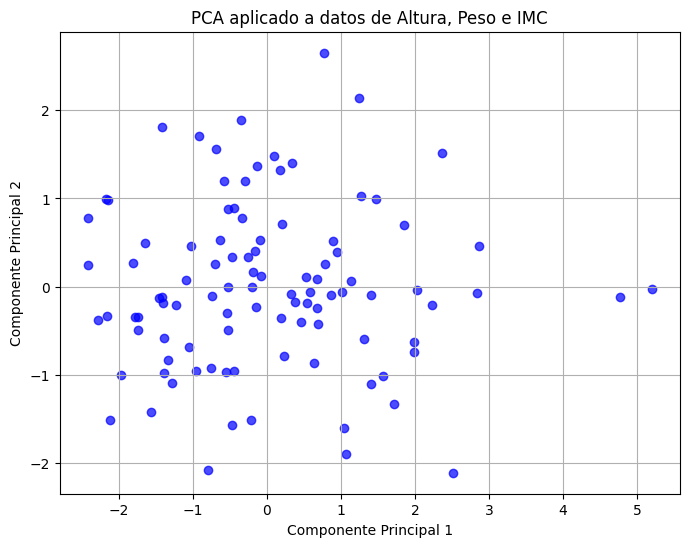

Varianza explicada por cada componente: [0.70553672 0.29209086]
Varianza total capturada por 2 componentes: 99.76%


In [ ]:
# # Clase Lunes 11/08/2025 sesión 3 del módulo 7
# 1. Código de ejemplo para PCA
# Este código demuestra cómo aplicar el Análisis de Componentes Principales (PCA) a un conjunto de datos simulado de altura, peso e Índice
# de Masa Corporal (IMC). El objetivo es reducir las tres variables a dos componentes principales para su visualización y análisis.
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Crear un conjunto de datos simulado con altura, peso e IMC
np.random.seed(42) # para reproducibilidad
n_muestras = 100

altura = np.random.normal(170, 10, n_muestras) # en cm
peso = np.random.normal(70, 15, n_muestras) # en Kg
imc = peso / (altura / 100) ** 2 # fórmula del IMC

# Construir el DataFrame
df = pd.DataFrame({'Altura': altura, 'Peso': peso, 'IMC': imc})

# 2. Normalizar los datos antes de aplicar PCA
# La normalización es crucial para que todas las variables tengan el mismo peso
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

# 3. Aplicar PCA para reducir de 3 a 2 dimensiones
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

# 4. Convertir los resultados de PCA a un DataFrame para fácil manipulación
df_pca = pd.DataFrame(x_pca, columns=['Componente 1', 'Componente 2'])

# 5. Visualizar los resultados
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['Componente 1'], df_pca['Componente 2'], alpha=0.7, color='blue')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA aplicado a datos de Altura, Peso e IMC')
plt.grid()
plt.show()

# 6. Explicar la varianza capturada por cada componente
# Esto muestra cuánta información (varianza) de los datos originales explica cada componente
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print(f"Varianza total capturada por 2 componentes: {pca.explained_variance_ratio_.sum() * 100:.2f}%")


Ejes: Los ejes representan los nuevos componentes principales creados por el algoritmo PCA. El eje horizontal es el "Componente Principal 1" y el eje vertical es el "Componente Principal 2".

Puntos: Cada punto azul en el gráfico representa una de las 100 muestras de datos originales simuladas (cada punto es una persona). Estas muestras tenían originalmente tres variables: altura, peso e IMC.

Proyección: El PCA ha tomado estos tres datos y los ha proyectado en un nuevo espacio de menor dimensionalidad, en este caso, un plano 2D, utilizando los dos componentes principales.

Varianza: La idea del PCA es encontrar nuevas variables (los componentes principales) que capturen la mayor cantidad de varianza de los datos originales. El "Componente Principal 1" es el eje que explica la mayor cantidad de varianza, y el "Componente Principal 2" explica la segunda mayor cantidad de varianza.

Interpretación: La distribución de los puntos en el gráfico permite visualizar patrones en los datos que no serían evidentes en un conjunto de datos de 3 o más dimensiones. En este caso, el gráfico muestra la relación entre las muestras en función de los dos componentes principales más importantes. Por ejemplo, podríamos interpretar que las personas con valores altos en el "Componente Principal 1" tienen una característica combinada de altura, peso e IMC muy diferente de aquellas con valores bajos en el mismo componente.

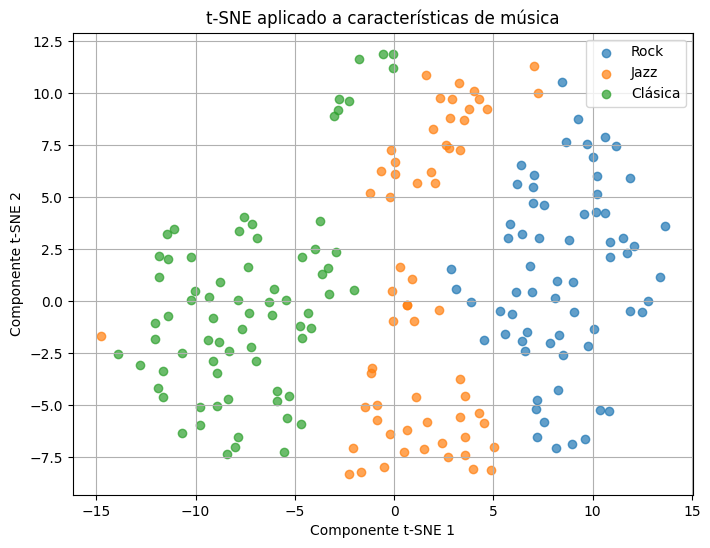

In [ ]:
# 2. Código de ejemplo para t-SNE
# Este código ilustra cómo utilizar t-Distributed Stochastic Neighbor Embedding (t-SNE) para visualizar un conjunto de datos
# simulado con características musicales, como género, tempo, intensidad y tonalidad. t-SNE es ideal para este tipo de datos
# porque es una técnica no lineal que preserva las relaciones locales, lo que ayuda a formar clústeres de géneros musicales
# similares en un espacio 2D.
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 1. Crear un conjunto de datos simulado con características musicales
np.random.seed(42) # para reproducibilidad
n_samples = 200

generos = np.random.choice(['Rock', 'Jazz', 'Clásica'], n_samples)
tempo = np.random.normal(120, 20, n_samples) # en BPM
intensidad = np.random.normal(0.7, 0.1, n_samples) # volumen normalizado
tonalidad = np.random.randint(0, 12, n_samples) # Do=0, Re=1, ... Si=11

# 2. Construir el DataFrame
df = pd.DataFrame({'Genero': generos, 'Tempo': tempo, 'Intensidad': intensidad, 'Tonalidad': tonalidad})

# 3. Convertir la variable categórica 'Genero' a valores numéricos
df['Genero'] = df['Genero'].astype('category').cat.codes
df1 = df.copy()

# 4. Normalizar los datos numéricos antes de aplicar t-SNE
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df1[['Genero', 'Tempo', 'Intensidad', 'Tonalidad']])

# 5. Aplicar t-SNE para reducir la dimensionalidad a 2 componentes
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_tsne = tsne.fit_transform(x_scaled)

# 6. Convertir los resultados a un DataFrame para la visualización
df_tsne = pd.DataFrame(x_tsne, columns=['Componente t-SNE 1', 'Componente t-SNE 2'])
df_tsne['Genero'] = generos # Agregar la columna original de géneros para colorear los puntos

# 7. Graficar los resultados
plt.figure(figsize=(8, 6))
for genero in ['Rock', 'Jazz', 'Clásica']:
    subset = df_tsne[df_tsne['Genero'] == genero]
    plt.scatter(subset['Componente t-SNE 1'], subset['Componente t-SNE 2'], label=genero, alpha=0.7)

plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.title('t-SNE aplicado a características de música')
plt.legend()
plt.grid(True)
plt.show()

Ejes: Los ejes X y Y representan los dos componentes principales creados por el algoritmo t-SNE. A diferencia de PCA, estos ejes no tienen una interpretación lineal directa en términos de varianza. En su lugar, el objetivo de t-SNE es preservar la estructura local de los datos.


Puntos: Cada punto en el gráfico representa una canción del conjunto de datos simulado. Las canciones tenían originalmente características como género, tempo, tonalidad e intensidad.


Colores: Los puntos están coloreados según el género musical al que pertenecen: azul para "Rock", naranja para "Jazz" y verde para "Clásica". Esto ayuda a visualizar cómo t-SNE ha agrupado los datos.


Clústeres: La característica principal del gráfico es que los puntos del mismo color se agrupan en clústeres distintos. Por ejemplo, las canciones de "Rock" están en su mayoría en la parte derecha, las de "Jazz" se concentran en el centro y las de "Clásica" están a la izquierda.


Interpretación: La agrupación en clústeres indica que las canciones de cada género son "vecinos cercanos" en el espacio de alta dimensionalidad original, es decir, son más similares entre sí que a las canciones de otros géneros . t-SNE ha logrado proyectar esta similitud local en un espacio 2D, haciendo que la separación de géneros sea visualmente clara y facilitando la interpretación de los patrones.

**Ejemplo: Detección de fraudes con autoencoders**
Escenario:
En una empresa de tarjetas de crédito, el 99% de las transacciones son legítimas y solo el 1% son fraudulentas.
Entrenar un modelo supervisado sería complicado porque no hay suficientes ejemplos de fraude.

Solución con Autoencoder:

Entrenamiento:

Se entrena el autoencoder solo con transacciones legítimas para que aprenda a reconstruir este tipo de datos.

Uso en producción:

Cuando llega una transacción nueva, el autoencoder intenta reconstruirla.

Si el error de reconstrucción es muy alto → es probable que sea una transacción fraudulenta, porque su patrón no se parece al de las transacciones normales.

Ventaja:

No necesita ejemplos de fraude para entrenar.

Detecta anomalías de forma no supervisada.

Interpretación del resultado

Error bajo → patrón normal.

Error alto → patrón sospechoso o anómalo.
Se define un umbral óptimo para decidir qué transacciones revisar manualmente.

In [ ]:
# Autoencoder para Detección de Anomalías (fraude simulado)
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# 1) Datos simulados
# ------------------
# "Normales": nube gaussiana
n_norm = 10000
X_norm = np.random.multivariate_normal(
    mean=[0,0,0,0,0,0,0,0,0,0],
    cov=np.diag([1,1,1,1,1,1,1,1,1,1]),
    size=n_norm
)
# Genera 10,000 puntos (“transacciones normales”) en un espacio de 10 variables (porque el mean y la diagonal de cov tienen 10 elementos).
# multivariate_normal crea puntos de una Gaussiana multivariante:
# Media en el origen ([0,…,0]): el “centro” de lo normal.
# Covarianza diagonal con 1’s: variables independientes entre sí, con varianza 1 (mismo “ancho” en cada eje).
# Resultado: una nube “redonda” y compacta alrededor de 0.

# "Anómalos": desplazados y con más dispersión (patrones raros)
n_anom = 400
X_anom = np.random.multivariate_normal(
    mean=[3,3,3,3,3,3,3,3,3,3],
    cov=np.diag([2,2,2,2,2,2,2,2,2,2]),
    size=n_anom
)
# Genera 400 puntos (“anomalías”) también en 10D.
# Diferencias clave respecto a las normales:
# Media desplazada a [3,…,3]: están lejos del centro normal → patrón distinto.
# Varianza 2 (en cada eje): nube más dispersa (más variabilidad) → mayor “rareza”.
# Resultado: puntos que no se parecen a los normales (tanto por posición como por dispersión).

X = np.vstack([X_norm, X_anom])
y = np.hstack([np.zeros(n_norm, dtype=int), np.ones(n_anom, dtype=int)])  # 0=normal, 1=anómalo
# X concatena verticalmente las dos nubes: tamaño total 10000 + 400 = 10400 filas × 10 columnas.
# y crea las etiquetas:
# 0 para normales,
# 1 para anómalas.
# Queda un dataset desbalanceado realista: anomalías ≈ 3.85% (400/10400), parecido a lo que pasa en fraude real.

# 2) Split (¡entrenamos solo con normales!)
# -----------------------------------------
X_tr_all, X_te, y_tr_all, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_tr = X_tr_all[y_tr_all==0]  # solo normales para entrenar el AE
# train_test_split divide el dataset en entrenamiento y prueba.
# test_size=0.3 → el 30% de los datos se reserva para prueba.
# stratify=y → garantiza que la proporción de normales y anómalos se mantiene en ambos conjuntos.
# random_state=42 → asegura reproducibilidad.
# X_tr se filtra para quedarse solo con los normales (y_tr_all==0)
# → Esto es clave en anomaly detection con autoencoders:
# entrenas el modelo solo con el patrón normal, para que después cualquier desviación genere un error de reconstrucción alto.

# 3) Escalado
# -----------
scaler = StandardScaler()
X_tr_std = scaler.fit_transform(X_tr)
X_te_std = scaler.transform(X_te)
# Se normalizan las variables:
# StandardScaler() → transforma cada columna a media 0 y desviación estándar 1.

# Importante:
# fit_transform en el entrenamiento (solo normales)
# transform en el test (normales y anómalos mezclados) usando los mismos parámetros del entrenamiento.
# Así evitas “contaminar” el escalado con información de anomalías.

# 4) Autoencoder sencillo
# -----------------------
input_dim = X_tr_std.shape[1]   # 10
encoding_dim = 4                # compresión 10 -> 4

inp = keras.Input(shape=(input_dim,), name="entrada")
z   = layers.Dense(8, activation="relu")(inp)
z   = layers.Dense(encoding_dim, activation="relu", name="latente")(z)
z   = layers.Dense(8, activation="relu")(z)
out = layers.Dense(input_dim, activation="linear")(z)  # datos estandarizados => salida lineal

auto = keras.Model(inp, out)
auto.compile(optimizer="adam", loss="mse")
# Arquitectura:
# Entrada de 10 features.
# Codificación: 10 → 8 → 4 neuronas → compresión.
# Decodificación: 4 → 8 → 10 neuronas.
# Activación relu en capas ocultas → introduce no linealidad.
# Activación linear en salida → apropiada porque los datos están estandarizados (no hay límite como [0,1]).
# Loss: MSE (error cuadrático medio) → mide qué tan diferente es la reconstrucción respecto al original.

cb = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
hist = auto.fit(
    X_tr_std, X_tr_std,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[cb],
    verbose=0
)

print("Mejor val_loss:", min(hist.history["val_loss"]))
# Entrenamos para reconstruir la misma entrada (X_tr_std como entrada y salida).
# validation_split=0.2 → usa el 20% de los datos de entrenamiento para validación.

# EarlyStopping:
# Si la val_loss no mejora en 5 épocas seguidas → detiene entrenamiento.
# restore_best_weights=True → se recuperan los pesos de la mejor época.
# epochs=100 y batch_size=128 son parámetros de entrenamiento.


# 5) Error de reconstrucción y umbral
# -----------------------------------
# a) Error en train (normales) para fijar umbral (p.ej., percentil 99)
rec_tr = auto.predict(X_tr_std, verbose=0)
err_tr = np.mean((X_tr_std - rec_tr)**2, axis=1)
thr = np.percentile(err_tr, 99)  # umbral estricto
# Se toma el percentil 99 de los errores en entrenamiento.
# Significa que el 99% de los normales reales caen por debajo de ese error.
# Si un punto nuevo tiene error mayor al umbral → se marca como posible anomalía.

Mejor val_loss: 0.5901529788970947


Ese valor significa que, durante el entrenamiento del autoencoder, la mejor pérdida de validación (val_loss) obtenida fue aproximadamente 0.59015.

En este contexto:

val_loss mide el error medio de reconstrucción (MSE) en el conjunto de validación.

Como entrenaste el autoencoder para reproducir entradas normales, ese número indica cuánto, en promedio, se equivocó el modelo al reconstruir datos normales que no vio durante el entrenamiento.

Mientras más bajo el val_loss, mejor está el autoencoder en aprender el patrón normal.

En detección de anomalías, ese error en datos normales sirve de referencia para fijar el umbral de detección:

Si el error de reconstrucción de un nuevo dato es mucho mayor que el típico de los datos normales (por ejemplo, más alto que el percentil 99 de errores normales), se marca como anómalo.

In [ ]:
# b) Error en test y decisión
rec_te = auto.predict(X_te_std, verbose=0)
err_te = np.mean((X_te_std - rec_te)**2, axis=1)
y_pred = (err_te > thr).astype(int)

print("Umbral elegido (p99 train):", round(thr, 6))
print("\nREPORTE (0=normal, 1=anómalo):")
print(classification_report(y_te, y_pred, digits=3))

# Métrica adicional (AUC usando error como puntaje)
auc = roc_auc_score(y_te, err_te)
print("ROC-AUC (mayor es mejor):", round(auc, 3))

Umbral elegido (p99 train): 1.619774

REPORTE (0=normal, 1=anómalo):
              precision    recall  f1-score   support

           0      1.000     0.991     0.995      3000
           1      0.821     0.992     0.898       120

    accuracy                          0.991      3120
   macro avg      0.910     0.992     0.947      3120
weighted avg      0.993     0.991     0.992      3120

ROC-AUC (mayor es mejor): 1.0


Umbral elegido: 1.619774
Es el límite que separa un dato normal de uno anómalo.

Se calculó usando el percentil 99 del error de reconstrucción de los datos normales de entrenamiento.

Todo dato con error > 1.619774 se clasifica como anómalo (1).

Reporte de clasificación
Clase	Significado	precision	recall	f1-score	support
0	Normal	1.000	0.991	0.995	3000
1	Anómalo	0.821	0.992	0.898	120

Precision (Precisión): de todos los que el modelo predijo como anómalos, el 82.1% realmente lo eran.

Recall (Sensibilidad): de todos los anómalos reales, el 99.2% fueron detectados.

F1-score: equilibrio entre precisión y recall.

Support: número real de ejemplos de esa clase en el conjunto de prueba.

Métricas globales
Accuracy: 99.1% → porcentaje total de predicciones correctas.

Macro avg: promedio simple entre clases (no ponderado por cantidad de ejemplos).

Weighted avg: promedio ponderado según la cantidad de datos por clase (más realista en datasets desbalanceados).

ROC-AUC = 1.0
Significa que el modelo separa perfectamente las distribuciones de errores entre normales y anómalos (al menos en este dataset simulado).

En la práctica, un 1.0 es rarísimo en datos reales, pero aquí es posible porque los datos fueron simulados con una separación muy clara.

Esto quiere decir que tu autoencoder aprendió muy bien el patrón normal, y casi todos los anómalos quedaron con errores de reconstrucción por encima del umbral. El único punto débil aquí es la precisión de 0.82 en anómalos, lo que significa que algunos normales fueron clasificados como anómalos (falsos positivos).



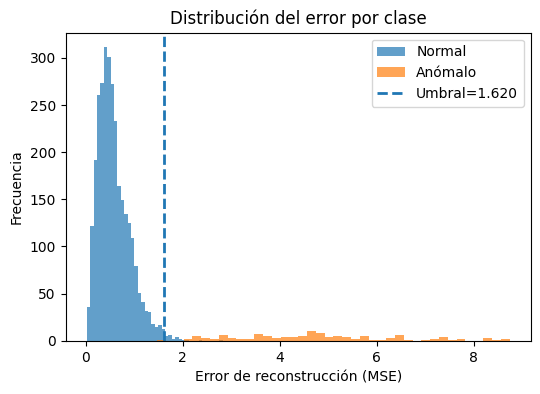

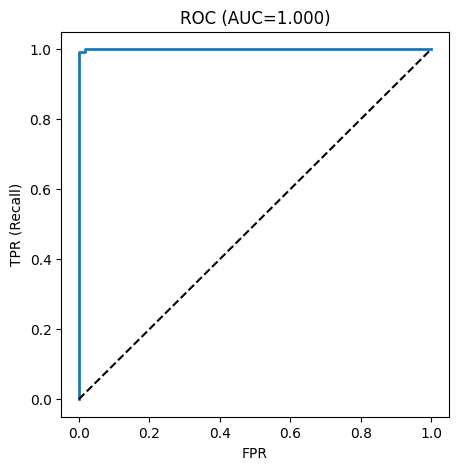

In [ ]:
# 6) Gráficos rápidos
# -------------------
# Histograma de errores por clase
plt.figure(figsize=(6,4))
plt.hist(err_te[y_te==0], bins=40, alpha=0.7, label="Normal")
plt.hist(err_te[y_te==1], bins=40, alpha=0.7, label="Anómalo")
plt.axvline(thr, ls="--", lw=2, label=f"Umbral={thr:.3f}")
plt.xlabel("Error de reconstrucción (MSE)")
plt.ylabel("Frecuencia")
plt.title("Distribución del error por clase")
plt.legend()
plt.show()
# Curva ROC
fpr, tpr, _ = roc_curve(y_te, err_te)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, lw=2)
plt.plot([0,1],[0,1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR (Recall)")
plt.title(f"ROC (AUC={auc:.3f})")
plt.show()

Histograma – Distribución del error por clase
Eje X (Error de reconstrucción – MSE)
Es la diferencia promedio al cuadrado entre los datos originales y su reconstrucción hecha por el autoencoder.

Valores bajos → el modelo reconstruye bien (probablemente datos normales).

Valores altos → el modelo no logra reconstruir bien (posibles anomalías).

Eje Y (Frecuencia)
Cantidad de observaciones que tienen un cierto valor de error.

Colores

Azul: Datos normales (etiqueta 0).

Naranja: Datos anómalos (etiqueta 1).

Línea vertical punteada
Representa el umbral elegido (percentil 99 de los errores en datos normales).

Todo punto a la derecha de esa línea se clasifica como “anómalo”.

A la izquierda → “normal”.

Interpretación:
Aquí se ve que la mayoría de datos normales están bien reconstruidos (errores pequeños), mientras que casi todos los anómalos tienen errores mucho más altos, lo que facilita su detección. El umbral está colocado de forma que captura la mayoría de los anómalos y pocos falsos positivos.

2. Curva ROC (Receiver Operating Characteristic)
Eje X (FPR – False Positive Rate)
Proporción de datos normales que se clasifican erróneamente como anómalos.

Eje Y (TPR – True Positive Rate o Recall)
Proporción de anómalos detectados correctamente.

Curva azul
Muestra el desempeño del modelo para diferentes umbrales.

Línea negra diagonal
Representa el azar (clasificador aleatorio). Un buen modelo debe estar muy por encima de esta línea.

AUC (Area Under Curve)
Valor entre 0 y 1 que mide qué tan bien separa el modelo las clases.

1.0: separación perfecta.

0.5: tan malo como adivinar al azar.

Interpretación:
El AUC de 1.0 indica que el autoencoder separa perfectamente datos normales y anómalos en este conjunto. La curva azul pegada a la esquina superior izquierda significa que logra alta detección de anomalías con casi ningún falso positivo.



**Otra base de datos:**
La base de datos MNIST (Modified National Institute of Standards and Technology database) es un conjunto de datos muy famoso en inteligencia artificial y aprendizaje automático, especialmente usado para problemas de reconocimiento de dígitos escritos a mano.

1. Origen
Fue creada por Yann LeCun, Corinna Cortes y Christopher Burges a finales de los 90’s.

Está basada en una base de datos más antigua del NIST (National Institute of Standards and Technology) de EE.UU., que tenía imágenes de dígitos escritos por empleados de la oficina postal y estudiantes.

Los autores la modificaron y estandarizaron para que fuera más adecuada como conjunto de referencia (benchmark) para la investigación.

2. Contenido
70,000 imágenes en escala de grises de dígitos del 0 al 9.

Tamaño de imagen: 28 × 28 píxeles → cada imagen es una matriz de 784 valores (intensidad 0 a 255).

60,000 imágenes de entrenamiento y 10,000 de prueba.

Etiquetas (labels) de 0 a 9 indicando qué número representa la imagen.

3. Propósito
Se diseñó como conjunto de datos estándar para probar y comparar modelos de reconocimiento de patrones.

La idea era que cualquier investigador pudiera:

Entrenar su modelo con las mismas imágenes.

Probarlo en el mismo conjunto de datos de prueba.

Comparar resultados de manera justa.

4. Usos principales
Reconocimiento óptico de caracteres (OCR).

Enseñar y experimentar con redes neuronales, SVM, k-NN, PCA, t-SNE, autoencoders, etc.

Evaluar mejoras en preprocesamiento de imágenes y técnicas de extracción de características.

5. Relevancia
Fue uno de los primeros conjuntos de datos masivos y accesibles para la comunidad.

A pesar de ser un problema “resuelto” (modelos modernos superan el 99.7% de precisión), sigue siendo un punto de partida clásico para aprender visión por computadora.

Ha inspirado bases de datos más complejas, como Fashion-MNIST (ropa), KMNIST (caracteres japoneses) y EMNIST (letras y números).

En resumen:
MNIST se creó para facilitar la investigación y comparación en reconocimiento de dígitos manuscritos, convirtiéndose en un estándar educativo y experimental en machine learning.

In [ ]:
# Ejemplo: Reconocimiento de dígitos manuscritos (MNIST reducido)
# Idea:
# Tenemos imágenes de dígitos manuscritos (0–9) del dataset MNIST.
# Cada imagen tiene 784 características (28×28 píxeles).
# Usamos PCA para reducir de 784 → 50 componentes y eliminar ruido.

# Luego usamos t-SNE para proyectar a 2D y visualizar cómo los dígitos se agrupan naturalmente.
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

rng = np.random.RandomState(42)
# StandardScaler → para escalar datos (media 0 y desviación estándar 1).
# PCA → reducción de dimensionalidad lineal.
# t-SNE → reducción no lineal para visualización.

# -------- Carga robusta --------
use_mnist = True
try:
    from tensorflow.keras.datasets import mnist
    (X_train, y_train), (X_test, y_test) = mnist.load_data()  # descarga desde mirror de Keras
    X = np.vstack([X_train, X_test])         # (70000, 28, 28)
    y = np.hstack([y_train, y_test])         # (70000,)
    X = X.reshape(len(X), -1).astype("float32")  # aplanar -> (70000, 784)
    print("Usando MNIST Keras:", X.shape)
except Exception as e:
    from sklearn.datasets import load_digits
    digits = load_digits()
    X = digits.data.astype("float32")        # (1797, 64)
    y = digits.target
    use_mnist = False
    print("Fallo MNIST; usando sklearn.digits:", X.shape, "Error:", type(e).__name__)

# Primera opción (try): carga el dataset MNIST desde Keras.
# Son imágenes de dígitos de 28×28 píxeles.
# Se combinan train y test (vstack y hstack) para tener todo junto.
# Se “aplanan” (reshape) a vectores de 784 elementos por imagen.

# Segunda opción (except): si falla (por ejemplo, por falta de conexión), carga el dataset digits de sklearn.
# Son imágenes de 8×8 píxeles (64 características).
# Esto asegura que el script siempre tenga datos aunque la descarga falle.

# -------- Submuestreo para rapidez (opcional) --------
n = 3000 if use_mnist else len(X)  # con MNIST toma 3000 puntos; con digits usa todos
idx = rng.choice(len(X), size=n, replace=False)
X = X[idx]; y = y[idx]
# Si es MNIST (muchos datos), se toma una muestra aleatoria de 3000 imágenes para que el cálculo sea rápido.
# Si es digits (pocos datos), se usan todos.
# idx es un array con índices aleatorios sin repetición (replace=False).

# -------- Escalado --------
X_scaled = StandardScaler().fit_transform(X)
# Estandariza cada característica → media 0, varianza 1.
# Esto es importante porque PCA es sensible a la escala.

# -------- PCA: 50 componentes (si hay menos, usa todas) --------
n_comp = min(50, X_scaled.shape[1])  # 784->50 para MNIST; 64->50 para digits
pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Varianza explicada por {n_comp} PCs: {pca.explained_variance_ratio_.sum():.2%}")
# n_comp: si hay muchas columnas (784 en MNIST), toma solo 50 componentes; si hay menos (64 en digits), usa todas.
# Se ajusta PCA y se transforma X_scaled.
# Se imprime la varianza total explicada → qué porcentaje de la información original está retenido en estas componentes.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Usando MNIST Keras: (70000, 784)
Varianza explicada por 50 PCs: 63.71%


Downloading data from ... mnist.npz

Está descargando el dataset MNIST desde el repositorio oficial de Keras en Google Cloud.

El archivo mnist.npz pesa unos 11 MB (11,490,434 bytes).

11490434/11490434 ... 0s

Significa que se descargaron 11,490,434 bytes completos.

Lo hizo en 0 segundos (probablemente por buena conexión o porque ya estaba en caché).

Usando MNIST Keras: (70000, 784)

Después de cargar y procesar los datos, tienes un array X de forma:

70,000 filas → una por cada imagen (60,000 de entrenamiento + 10,000 de prueba).

784 columnas → cada imagen de 28×28 píxeles se aplanó en un vector de 784 valores.

Varianza explicada por 50 PCs: 63.71%

El PCA redujo la dimensionalidad de 784 a 50 componentes principales.

Con esas 50 componentes, se retiene aproximadamente el 63.71% de la información (varianza) de los datos originales.

Esto significa que casi un 36% de la variabilidad se pierde al reducir, pero aún así se conserva la mayoría de la estructura global.

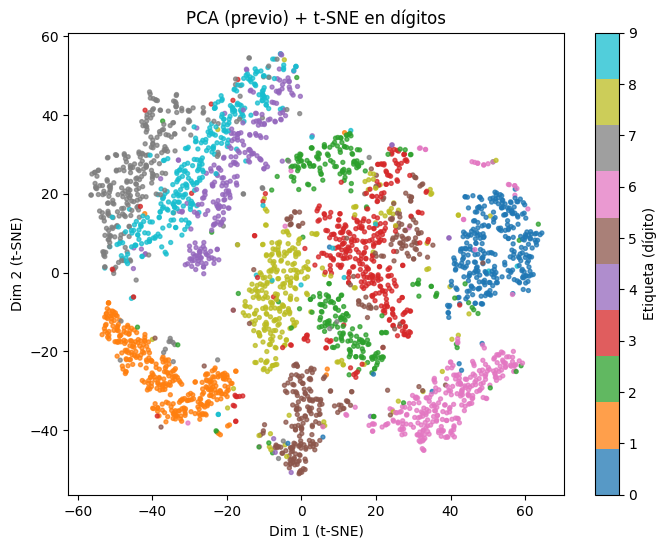

In [ ]:
# -------- t-SNE (2D) --------
tsne = TSNE(
    n_components=2,
    perplexity=30,          # prueba 5/30/50 para comparar
    init="pca",
    learning_rate="auto",
    random_state=42
)
# TSNE (t-distributed Stochastic Neighbor Embedding) es un algoritmo de reducción de dimensionalidad no lineal, ideal para visualización.
# n_components=2 → queremos mapear los datos a 2 dimensiones (para graficar en un plano).
# perplexity=30 → controla el tamaño "efectivo" del vecindario usado para comparar similitudes (valores bajos detectan microestructuras,
# valores altos estructuras más globales).
# init="pca" → en vez de empezar desde posiciones aleatorias, usa el resultado del PCA como punto de partida.
# learning_rate="auto" → ajusta automáticamente la velocidad de aprendizaje.
# random_state=42 → asegura que cada ejecución dé el mismo resultado.

X_tsne = tsne.fit_transform(X_pca)
# Aquí se entrena t-SNE con los datos reducidos por PCA (X_pca), no con los originales, para:
# Reducir tiempo de cómputo.
# Evitar ruido de alta dimensión.
# El resultado X_tsne es un array con 2 columnas (las coordenadas en el nuevo espacio 2D) y n filas (una por cada imagen).

# -------- Plot --------
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, s=8, cmap="tab10", alpha=0.75)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label("Etiqueta (dígito)")
plt.title("PCA (previo) + t-SNE en dígitos")
plt.xlabel("Dim 1 (t-SNE)"); plt.ylabel("Dim 2 (t-SNE)")
plt.show()

Ejes ("Dim 1" y "Dim 2")

No representan valores originales como “pixeles” o “números” concretos.

Son coordenadas en el espacio 2D que t-SNE generó para que los puntos con imágenes similares estén cerca, y los diferentes lejos.

Colores

Cada color corresponde a la etiqueta real del dígito (0–9), según la barra de color a la derecha.

Por ejemplo:

Azul (abajo a la derecha) son dígitos “0”.

Rojo en el centro son dígitos “2”.

Naranja abajo a la izquierda son “1”, etc.

Agrupamientos (clusters)

Los puntos con el mismo color tienden a formar agrupaciones separadas → significa que las imágenes de ese dígito tienen patrones muy parecidos.

Algunas clases están muy compactas (ej. el “0” y el “1” son grupos bien definidos).

Otras están más dispersas o mezcladas (ej. el “5” y el “3”) porque visualmente pueden parecerse en ciertas escrituras.

PCA previo

Antes de aplicar t-SNE, se redujo la dimensión de 784 píxeles a 50 componentes principales (PCA).

Esto elimina ruido y acelera t-SNE, sin perder demasiada información importante.

Lo que significa para el modelo

Si un modelo ve datos como estos, puede aprender fácilmente a separar los dígitos en base a sus patrones visuales.

t-SNE no sirve para predecir directamente, sino para explorar y visualizar relaciones en datos de alta dimensión.

Conclusión:
Este gráfico confirma que el dataset MNIST tiene separabilidad natural: las imágenes de cada dígito se agrupan de forma clara en un espacio de características, lo que justifica por qué algoritmos simples pueden alcanzar alta precisión en este problema.

In [ ]:
# Usaremos el Breast Cancer Wisconsin (Diagnostic) que viene en scikit-learn (no necesitas descargar nada). El objetivo: visualizar,
# reducir dimensión y mejorar un clasificador para distinguir benigno vs maligno.
# 1) Setup y datos (Breast Cancer – UCI, vía sklearn)
# 1) SETUP Y CARGA DE DATOS
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

# Cargar dataset real (diagnóstico de cáncer de mama)
data = load_breast_cancer()
X = data.data          # 30 características de imagen (textura, perímetro, radio, etc.)
y = data.target        # 0 = maligno, 1 = benigno
feature_names = data.feature_names
target_names = data.target_names

print("Shape X:", X.shape)   # (n_muestras, 30)
print("Clases:", dict(zip([0,1], target_names)))

# Entrenamiento / prueba
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Estandarización (muy importante para PCA / t-SNE / SVM)
scaler = StandardScaler()
X_tr_std = scaler.fit_transform(X_tr)
X_te_std = scaler.transform(X_te)

Shape X: (569, 30)
Clases: {0: np.str_('malignant'), 1: np.str_('benign')}


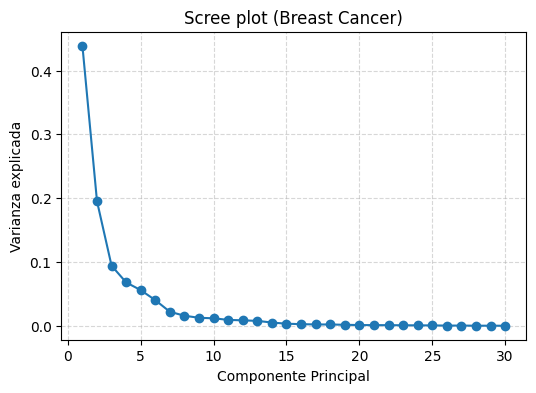

Componentes necesarios para ≥95% varianza: 10


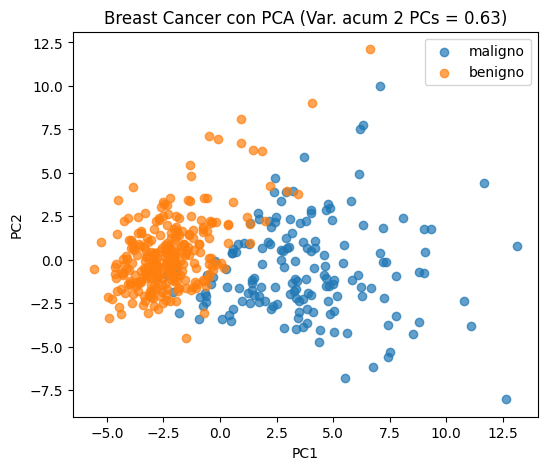

In [ ]:
# 2) PCA: varianza explicada + visualización 2D
# =========================
# 2) PCA: VARIANZA Y 2D
# =========================
from sklearn.decomposition import PCA

# Ajustamos PCA con todos los componentes (30)
pca_full = PCA().fit(X_tr_std)

# Scree plot: cuánta varianza explica cada PC
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, X_tr_std.shape[1]+1), pca_full.explained_variance_ratio_, marker="o")
plt.title("Scree plot (Breast Cancer)")
plt.xlabel("Componente Principal")
plt.ylabel("Varianza explicada")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# ¿Cuántos componentes para 95%?
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
k95 = np.argmax(var_acum >= 0.95) + 1
print(f"Componentes necesarios para ≥95% varianza: {k95}")

# Visualización 2D (PC1 vs PC2)
pca2 = PCA(n_components=2, random_state=42)
X_tr_pca2 = pca2.fit_transform(X_tr_std)
X_te_pca2 = pca2.transform(X_te_std)

plt.figure(figsize=(6,5))
plt.scatter(X_tr_pca2[y_tr==0,0], X_tr_pca2[y_tr==0,1], alpha=0.7, label="maligno")
plt.scatter(X_tr_pca2[y_tr==1,0], X_tr_pca2[y_tr==1,1], alpha=0.7, label="benigno")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Breast Cancer con PCA (Var. acum 2 PCs = {pca2.explained_variance_ratio_.sum():.2f})")
plt.legend()
plt.show()

Qué representan los puntos

Cada punto es un paciente del dataset de cáncer de mama (Breast Cancer Wisconsin).

El color indica su clase real:

Azul = maligno.

Naranja = benigno.

Por qué usar PCA

El dataset original tiene 30 variables (medidas de características de células tumorales).

El PCA las combinó en solo 2 variables (PC1 y PC2) que retienen un 63% de toda la información (varianza) del dataset.

Lo que muestra la nube de puntos

Aunque hay cierto solapamiento, los benignos tienden a agruparse a la izquierda (valores más negativos en PC1) y los malignos a la derecha (valores más positivos en PC1).

Esto significa que el PCA logró capturar información que diferencia en parte ambas clases.

El eje PC1 parece ser el más importante para distinguir entre benignos y malignos.

PC2 agrega algo de información extra, pero no separa tan claramente.

Limitaciones

Solo vemos el 63% de la varianza, así que no es una separación perfecta.

El solapamiento en la zona central muestra que algunos casos son difíciles de clasificar con solo 2 PCs.

Este gráfico nos permite ver cómo un algoritmo no supervisado (PCA) puede reducir la complejidad del problema y revelar que, aunque no le dimos las etiquetas, los pacientes con tumores benignos y malignos tienden a ocupar regiones distintas del espacio de características comprimido.

El PC1 explica alrededor del 43-44% de toda la varianza → es el más importante.

El PC2 explica cerca del 20%.

Juntos, los dos primeros PCs explican alrededor del 63% de la información total.

A partir del PC3, la contribución de cada componente baja mucho (menos del 10%), y la curva se aplana.

Punto de codo (elbow)

La gráfica tiene un “codo” alrededor del componente 3 o 4.

Este punto indica que después de ahí, agregar más componentes aporta poca varianza extra, y puede no justificar el aumento de complejidad.

Conclusión práctica

Para este dataset, si quieres reducir la dimensionalidad con PCA, 2 a 4 componentes principales ya retienen la mayor parte de la información relevante.

Esto ayuda a simplificar modelos, visualizar datos y reducir ruido.


“Este gráfico nos ayuda a decidir cuántos ejes conservar para describir bien la información original. Si nuestro objetivo fuera visualizar o entrenar un modelo más simple, probablemente bastaría con los 2 o 3 primeros PCs, que ya capturan casi toda la variabilidad importante.”

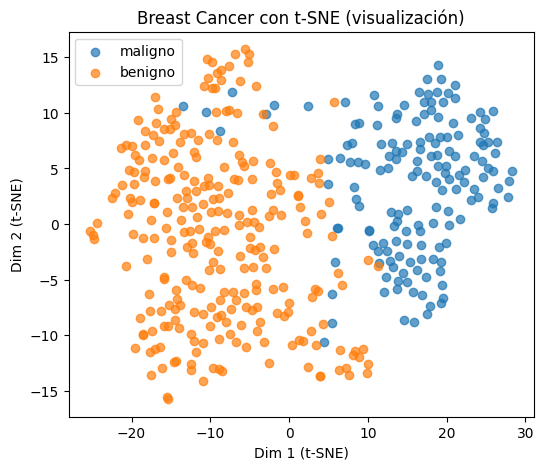

In [ ]:
# 3) t-SNE: estructura local (solo para visualización)
# =========================
# 3) t-SNE: ESTRUCTURA LOCAL
# =========================
from sklearn.manifold import TSNE

# t-SNE es lento; usa 2D para visualización. Juega con 'perplexity' (5-50)
tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=42)
X_tr_tsne = tsne.fit_transform(X_tr_std)

plt.figure(figsize=(6,5))
plt.scatter(X_tr_tsne[y_tr==0,0], X_tr_tsne[y_tr==0,1], alpha=0.7, label="maligno")
plt.scatter(X_tr_tsne[y_tr==1,0], X_tr_tsne[y_tr==1,1], alpha=0.7, label="benigno")
plt.xlabel("Dim 1 (t-SNE)")
plt.ylabel("Dim 2 (t-SNE)")
plt.title("Breast Cancer con t-SNE (visualización)")
plt.legend()
plt.show()

Eje X (Dim 1) y Eje Y (Dim 2): son dimensiones artificiales creadas por el algoritmo t-SNE, que no tienen un significado físico directo.

Los puntos azules representan tumores malignos.

Los puntos naranjas representan tumores benignos.

Qué nos dice la separación

Observamos dos grupos claros:

Un grupo a la izquierda (mayoritariamente benignos).

Un grupo a la derecha (mayoritariamente malignos).

Esto indica que las características originales del dataset contienen información suficiente para distinguir ambos tipos de tumores.

Por qué t-SNE es útil aquí

A diferencia del PCA (que maximiza varianza global), el t-SNE preserva la estructura local de los datos (vecinos cercanos).

Esto es útil para encontrar patrones no lineales y separar mejor clases que en PCA podrían verse más mezcladas.

Conclusión práctica

El modelo t-SNE nos confirma que los casos benignos y malignos tienden a formar clusters bien diferenciados en el espacio de características.

Esto es prometedor para crear modelos de clasificación efectivos, ya que la separación visual sugiere que los datos son separables.

Ejemplo: Imaginen que cada tumor es una persona en una fiesta. PCA es como mirar la fiesta desde arriba y ver la forma general de la multitud. t-SNE, en cambio, baja al piso y observa quién está hablando con quién, agrupando a las personas por afinidad. Por eso vemos los grupos más definidos aquí.

In [ ]:
# 4) Selección de características (filtro, wrapper, embebido) + comparación
# =========================
# 4) SELECCIÓN DE CARACTERÍSTICAS + COMPARACIÓN
# tres enfoques distintos para la selección de características —filtro, wrapper y embebido
# 1. ¿Qué es la selección de características?
# Es el proceso de elegir un subconjunto de las variables originales (features) que sean más relevantes para el modelo.
# Ayuda a mejorar la precisión.
# Reduce el tiempo de entrenamiento.
# Evita el sobreajuste.
# Hace el modelo más interpretable.


# =========================
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# (a) FILTRO: quedarnos con 10 mejores por Información Mutua.
# A) Método de filtro (Filter Method)
# Selecciona características antes de entrenar el modelo.
# Usa métricas estadísticas (correlación, chi-cuadrado, ANOVA, información mutua, etc.).
# Ejemplo: quedarse con las variables que tengan mayor correlación con la variable objetivo.
# Ventaja: rápido y no depende de un modelo específico.
# Desventaja: no tiene en cuenta la interacción entre variables.
pipe_filter = Pipeline([
    ("scaler", StandardScaler()),
    ("kbest", SelectKBest(mutual_info_classif, k=10)),
    ("clf", LogisticRegression(max_iter=5000))
])
# Pipeline: Es una forma de encadenar varias etapas de procesamiento y modelado para que se ejecuten en secuencia.
# "scaler" → StandardScaler(): Estandariza las variables para que tengan media 0 y desviación estándar 1 (muy útil en modelos sensibles a escalas).
# "kbest" → SelectKBest(mutual_info_classif, k=10): Aplica un método de selección de características tipo filtro usando la métrica de mutual information
# para seleccionar las 10 mejores características.
# "clf" → LogisticRegression(max_iter=5000): Clasificador de regresión logística. El parámetro max_iter es alto para asegurar la convergencia.

acc_filter = cross_val_score(pipe_filter, X, y, cv=cv).mean()
# cross_val_score: Evalúa el pipeline usando validación cruzada con cv particiones.
# Calcula la exactitud media (mean()) sobre todas las particiones.
# Esto te da el rendimiento promedio del modelo usando solo las 10 características seleccionadas.
pipe_filter.fit(X, y)
# Entrena todo el pipeline (escalado → selección de características → clasificación) con todos los datos.
mask_filter = pipe_filter.named_steps["kbest"].get_support()
# named_steps["kbest"]: Accede al paso SelectKBest dentro del pipeline.
# .get_support(): Devuelve un array booleano indicando qué columnas fueron seleccionadas (True = seleccionada, False = descartada).
print(f"[Filtro] Acc media 5-fold: {acc_filter:.3f}")
print("Top 10 (Filtro):", feature_names[mask_filter])

# (b) WRAPPER: RFE con Regresión Logística, dejamos 10 features
# Método envolvente (Wrapper Method) — ej. RFE
# Usa un modelo predictivo para evaluar conjuntos de características.
# RFE (Recursive Feature Elimination) elimina las menos importantes y se queda con las más relevantes.
# Ventaja: considera interacciones entre variables.
# Desventaja: más lento, porque entrena muchos modelos.
rfe = RFE(estimator=LogisticRegression(max_iter=5000), n_features_to_select=10)
# RFE (Recursive Feature Elimination):
# Es un método wrapper que entrena un modelo (en este caso una Regresión Logística).
# Calcula la importancia de cada variable.
# Elimina la menos importante.
# Repite el proceso hasta quedarse con el número deseado de características.
# estimator=LogisticRegression(max_iter=5000): Usa la regresión logística para estimar la importancia de cada variable.
# n_features_to_select=10: Queremos quedarnos con 10 características.


pipe_rfe = Pipeline([
    ("scaler", StandardScaler()),
    ("rfe", rfe),
    ("clf", LogisticRegression(max_iter=5000))
])
# Este pipeline asegura que:
# Se estandarizan las variables (importante para la regresión logística).
# Se seleccionan las mejores 10 características mediante RFE.
# Se entrena un clasificador final con las características seleccionadas.
acc_rfe = cross_val_score(pipe_rfe, X, y, cv=cv).mean()
# Evalúa el pipeline usando validación cruzada con cv particiones.
# Calcula la exactitud promedio del modelo después de la selección de variables.


pipe_rfe.fit(X, y)
# Entrena el pipeline con todos los datos para obtener el conjunto final de variables seleccionadas.
mask_rfe = pipe_rfe.named_steps["rfe"].get_support()
# Accede al paso "rfe" dentro del pipeline.
# .get_support() devuelve un array booleano donde True indica que la característica fue seleccionada.
print(f"[Wrapper-RFE] Acc media 5-fold: {acc_rfe:.3f}")
print("Top 10 (RFE):", feature_names[mask_rfe])
# Muestra la exactitud promedio lograda con las características seleccionadas.
# Lista las 10 características más relevantes según RFE.

# (c) EMBEBIDO: L1 (Lasso) en Regresión Logística
# Método embebido (Embedded Method) — ej. penalización L1
# Selección de variables durante el entrenamiento del modelo.
# Se basa en modelos que pueden asignar importancia a cada característica (p. ej. regresión logística con L1, árboles de decisión).
# Ventaja: combina la rapidez de los filtros con la precisión de los wrappers.
# Desventaja: depende del modelo elegido.
pipe_l1 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(penalty="l1", solver="saga", C=1.0, max_iter=5000))
])
# StandardScaler(): estandariza las variables para que todas estén en la misma escala.
# LogisticRegression(penalty="l1", solver="saga", ...):
# penalty="l1" → aplica regularización Lasso a la regresión logística.
# La regularización L1 fuerza a que muchos coeficientes sean exactamente 0, eliminando así variables poco relevantes.
# solver="saga" es necesario para manejar L1 en regresión logística con muchos datos.
# C=1.0 → inverso de la fuerza de regularización (valores pequeños ⇒ más regularización).
# max_iter=5000 asegura convergencia.
# Esto es un método embebido porque la selección de características ocurre dentro del entrenamiento del modelo gracias a la regularización.
acc_l1 = cross_val_score(pipe_l1, X, y, cv=cv).mean()
# Calcula la exactitud promedio usando validación cruzada.
# Mide el rendimiento del modelo con regularización L1.
pipe_l1.fit(X, y)
# Entrena el pipeline con todos los datos.
coef = pipe_l1.named_steps["clf"].coef_
# .coef_ devuelve los coeficientes de cada variable para cada clase.
# En clasificación multiclase, esto es una matriz (clases × variables).
imp = np.mean(np.abs(coef), axis=0)  # importancia media por feature
# np.abs(coef) → tomamos el valor absoluto (importa la magnitud, no el signo).
# np.mean(..., axis=0) → promediamos por columna (si hay varias clases).
# Resultado: un vector con la importancia promedio de cada característica.
rank_idx = np.argsort(imp)[::-1][:10]
# np.argsort(imp) ordena las variables de menor a mayor importancia.
# [::-1] invierte el orden (mayor a menor).
# [:10] toma las 10 primeras.
print(f"[Embebido-L1] Acc media 5-fold: {acc_l1:.3f}")
print("Top 10 (L1):", feature_names[rank_idx])
# Muestra la exactitud promedio.
# Lista las 10 características más relevantes según la regularización L1.

# Ejemplo real para explicar
# En medicina, si tenemos 50 pruebas diagnósticas posibles para predecir si un paciente tiene una enfermedad, la selección de
# características ayudaría a identificar cuáles 2 o 3 son realmente necesarias, ahorrando tiempo y dinero, y manteniendo la precisión
# del diagnóstico.

[Filtro] Acc media 5-fold: 0.956
Top 10 (Filtro): ['mean radius' 'mean perimeter' 'mean area' 'mean concavity'
 'mean concave points' 'area error' 'worst radius' 'worst perimeter'
 'worst area' 'worst concave points']
[Wrapper-RFE] Acc media 5-fold: 0.965
Top 10 (RFE): ['mean concave points' 'radius error' 'area error' 'compactness error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst concavity' 'worst concave points']
[Embebido-L1] Acc media 5-fold: 0.970
Top 10 (L1): ['radius error' 'worst radius' 'worst area' 'worst texture'
 'worst concave points' 'worst concavity' 'mean concave points'
 'compactness error' 'worst perimeter' 'worst symmetry']


Interpretación paso a paso
1. [Filtro]
Acc media 5-fold: 0.956 → con las 10 variables seleccionadas por un método estadístico previo (probablemente SelectKBest), el modelo logra un 95.6% de precisión promedio.

Top 10 seleccionadas:
mean radius, mean perimeter, mean area, mean concavity,
mean concave points, area error, worst radius, worst perimeter,
worst area, worst concave points
El criterio de selección se basó únicamente en la relación estadística entre cada variable y la clase, sin tener en cuenta interacciones entre variables.

2. [Wrapper - RFE]
Acc media 5-fold: 0.965 → al usar RFE (Recursive Feature Elimination), la precisión sube a 96.5%.

Top 10 seleccionadas:
mean concave points, radius error, area error, compactness error,
worst radius, worst texture, worst perimeter, worst area,
worst concavity, worst concave points
Aquí el conjunto de variables cambia un poco: aparecen más variables de tipo “error” y “worst” (medidas extremas de las características), lo que sugiere que RFE detecta que esas aportan más información predictiva.

3. [Embebido - L1]
Acc media 5-fold: 0.970 → la mejor precisión: 97.0%.

Top 10 seleccionadas:
radius error, worst radius, worst area, worst texture,
worst concave points, worst concavity, mean concave points,
compactness error, worst perimeter, worst symmetry
La selección se hizo durante el entrenamiento del modelo, usando regularización L1 que “pone a cero” los coeficientes menos relevantes.

Prioriza características relacionadas con la morfología extrema del tumor (“worst...”) y métricas de error.

Conclusiones
El método L1 obtuvo la mejor precisión (97%), seguido por RFE (96.5%) y Filtro (95.6%).

Aunque hay diferencias en las variables seleccionadas, hay coincidencias importantes:

worst radius, worst area, worst perimeter, worst concave points, mean concave points aparecen en más de un método.

Esto sugiere que esas son características clave para diferenciar entre tumores benignos y malignos.

En un caso real (como diagnóstico de cáncer de mama), estas técnicas permiten reducir el número de pruebas o mediciones necesarias, manteniendo una alta precisión en la detección.

[PCA+SVM] Acc media 5-fold: 0.975

REPORTE DE CLASIFICACIÓN (TEST):
              precision    recall  f1-score   support

   malignant       0.96      0.98      0.97        53
      benign       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



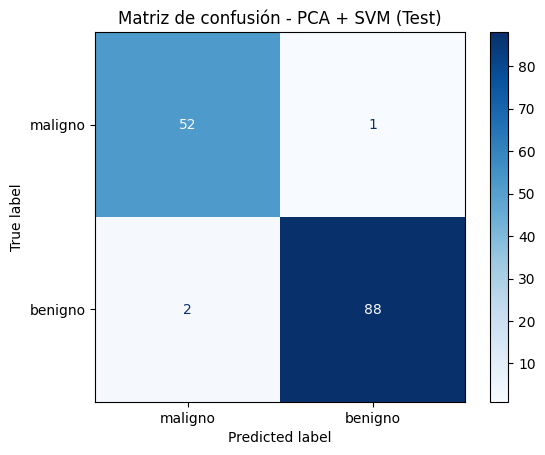

In [ ]:
# 5) Pipeline: PCA + SVM (clasificador compacto y potente)
# =========================
# 5) PIPELINE: PCA + SVM
# =========================
# Se trata de encadenar en un mismo flujo tres pasos para clasificar:
# Estandarizar las variables
# StandardScaler() pone todas las features en la misma escala (media 0, desv. 1).
# Evita que una variable “grande” domine y es clave para SVM.

# Reducir dimensión con PCA
# PCA(n_components=k) proyecta los datos a k componentes que capturan casi toda la varianza (p. ej., ≥95%).
# Beneficios: menos ruido/colinealidad, más rapidez, y a veces mejor generalización.

# Clasificar con SVM ( Support Vector Machine o en español Máquina de Vectores de Soporte.)
# SVC(Support Vector Classifier-Clasificador de Vectores de Soporte) (lineal o, más común, RBF (Radial Basis Function (Función de Base Radial).))
# aprende una frontera de decisión en ese espacio comprimido.En el contexto de SVM, RBF es un tipo de kernel que se usa para transformar los datos
# a un espacio de mayor dimensión, lo que permite que el clasificador encuentre una frontera de decisión no lineal.
# Hiperparámetros típicos: C (regularización) y gamma (solo en RBF).
# ¿Por qué en un Pipeline?
# Evita fugas de información: en validación cruzada, el scaling y el PCA se ajustan solo con el fold de entrenamiento.
# Hace fácil buscar hiperparámetros (GridSearch/RandomizedSearch) de PCA y SVM a la vez.

# En el siguiente código se está implementando un clasificador SVM con kernel RBF, pero antes de entrenarlo aplica PCA para reducir la dimensionalidad.

from sklearn.svm import SVC

# Reducimos a k95 componentes (≈95% varianza) y entrenamos SVM
pca_k = PCA(n_components=k95, random_state=42)
# PCA = Principal Component Analysis (Análisis de Componentes Principales).
# n_components=k95 significa que reducirá los datos a tantas componentes como sean necesarias para explicar aproximadamente el 95% de la varianza
# Sirve para:
# Reducir ruido.
# Disminuir el tiempo de entrenamiento.
# Evitar sobreajuste si hay muchas variables.

clf_svm = SVC(kernel="rbf", C=2.0, gamma="scale", probability=True, random_state=42)
# kernel="rbf" → usa el kernel de base radial para manejar fronteras de decisión no lineales.
# C=2.0 → controla el equilibrio entre un margen ancho y pocos errores de clasificación
# (mayor C → menos errores en entrenamiento, pero más riesgo de sobreajuste).
# gamma="scale" → la escala automática para el parámetro gamma del kernel RBF.
# probability=True → permite calcular probabilidades de pertenencia a cada clase.
# random_state=42 → para resultados reproducibles.

pipe_pca_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", pca_k),
    ("svm", clf_svm)
])
# Aquí creas un pipeline con 3 pasos secuenciales:
# "scaler": estandariza los datos con StandardScaler() (media 0, desviación estándar 1) → muy importante para SVM.
# "pca": aplica PCA para reducir la dimensionalidad.
# "svm": entrena el SVM con los datos ya reducidos.
# El pipeline asegura que todo el flujo se aplique igual tanto en entrenamiento como en validación y test.

acc_cv = cross_val_score(pipe_pca_svm, X, y, cv=cv).mean()
print(f"[PCA+SVM] Acc media 5-fold: {acc_cv:.3f}")
# cross_val_score → realiza validación cruzada usando cv (en este caso 5-fold).
# Calcula la media de exactitud (accuracy) en los 5 pliegues.
# Se imprime el resultado.

# Entrenamos y evaluamos en test
pipe_pca_svm.fit(X_tr, y_tr)
y_pred = pipe_pca_svm.predict(X_te)
# .fit(X_tr, y_tr): entrena todo el pipeline (escalado + PCA + SVM) con los datos de entrenamiento.
# .predict(X_te): predice las clases de los datos de prueba.

print("\nREPORTE DE CLASIFICACIÓN (TEST):")
print(classification_report(y_te, y_pred, target_names=target_names))

cm = confusion_matrix(y_te, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["maligno","benigno"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - PCA + SVM (Test)")
plt.show()

Resultado de validación cruzada
[PCA+SVM] Acc media 5-fold: 0.975
Accuracy medio en validación cruzada de 5 pliegues: 97.5%

Significa que, en promedio, el modelo clasificó correctamente el 97.5% de las muestras en validación.

Ya nos indicaba que el modelo era muy preciso antes de usar el conjunto de prueba.

Interpretación de métricas:
Precision (Precisión):

Malignant: 0.96 → De todos los casos predichos como malignos, el 96% eran realmente malignos.

Benign: 0.99 → De todos los casos predichos como benignos, el 99% eran realmente benignos.

Recall (Sensibilidad):

Malignant: 0.98 → El modelo identificó correctamente el 98% de todos los casos malignos reales.

Benign: 0.98 → El modelo identificó correctamente el 98% de todos los casos benignos reales.

F1-score:

Es la media armónica entre precision y recall.

Ambos valores cercanos a 1 indican un excelente equilibrio entre falsos positivos y falsos negativos.

Accuracy:
Exactitud global: 0.98 (98%), lo que significa que de las 143 muestras de prueba, el modelo clasificó bien 140 y se equivocó en solo 3.

Interpretación de la matriz de confusión
El gráfico muestra:

Predicho: Maligno	Predicho: Benigno
Real: Maligno	52	1
Real: Benigno	2	88

52 casos malignos reales fueron clasificados correctamente como malignos (verdaderos positivos).

1 caso maligno real fue clasificado como benigno (falso negativo).

88 casos benignos reales fueron clasificados correctamente como benignos (verdaderos negativos).

2 casos benignos reales fueron clasificados como malignos (falsos positivos).

Conclusión:
El modelo PCA + SVM con kernel RBF es altamente preciso para este problema de diagnóstico de cáncer de mama.

Los errores son muy pocos y se reparten entre ambas clases, lo cual indica que no hay un sesgo fuerte hacia una sola clase.

Ventaja del enfoque: PCA reduce dimensionalidad → SVM maneja mejor la separación → se obtiene un modelo rápido, compacto y con gran rendimiento.

In [ ]:
# 6) Autoencoder: compresión no lineal + usar latente para clasificar
# =========================
# 6) AUTOENCODER: COMPRESIÓN + CLASIFICACIÓN
# =========================
# Esa parte del código se refiere a una técnica de aprendizaje profundo llamada Autoencoder (o autocodificador).
#  ¿Qué es un Autoencoder?
# Un autoencoder es una red neuronal diseñada para aprender una representación comprimida (latente) de los datos y luego poder reconstruirlos.
# Se compone de dos partes:

# Encoder (codificador) → comprime los datos de entrada a un espacio de menor dimensión (espacio latente).

# Decoder (decodificador) → intenta reconstruir la entrada original a partir de esa representación comprimida.

#  Ejemplo mental:
# Es como comprimir un archivo en .zip (encoder) y luego descomprimirlo (decoder).
# La idea es que la compresión conserve las características más importantes.

#  En este caso (compresión + clasificación)
# Aquí no se usa el autoencoder para reconstruir imágenes o datos, sino para:
# Reducir la dimensionalidad de forma no lineal (mucho más flexible que PCA).
# Tomar esa representación latente comprimida y usarla como entrada a un clasificador (por ejemplo, un modelo de Logistic Regression, SVM, etc.).

# Ventaja frente a PCA:
# PCA → reducción lineal (solo combina variables de forma lineal).
# Autoencoder → puede aprender relaciones no lineales, capturando patrones más complejos.

# Flujo de trabajo típico en este caso

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_tr_std.shape[1]  # 30
encoding_dim = 8               # compactamos fuerte: 30 -> 8

# Definimos autoencoder simple (30->16->8->16->30)
inp = keras.Input(shape=(input_dim,), name="entrada")
z = layers.Dense(16, activation="relu")(inp)
z = layers.Dense(encoding_dim, activation="relu", name="latente")(z)
z = layers.Dense(16, activation="relu")(z)
out = layers.Dense(input_dim, activation="linear")(z)  # regresión a X (no está en [0,1])

auto = keras.Model(inp, out)
auto.compile(optimizer="adam", loss="mse")
auto.summary()

hist = auto.fit(
    X_tr_std, X_tr_std,
    validation_data=(X_te_std, X_te_std),
    epochs=40, batch_size=64, verbose=0
)

# Extraemos el encoder
encoder = keras.Model(inp, auto.get_layer("latente").output)

Z_tr = encoder.predict(X_tr_std)
Z_te = encoder.predict(X_te_std)
print("Formas latentes:", Z_tr.shape, Z_te.shape)

# Clasificamos con la latente (por ejemplo, Logistic Regression)
from sklearn.linear_model import LogisticRegression
clf_lat = LogisticRegression(max_iter=5000)
clf_lat.fit(Z_tr, y_tr)
y_pred_lat = clf_lat.predict(Z_te)

print("\nClasificación usando SOLO la latente (8D):")
print(classification_report(y_te, y_pred_lat, target_names=target_names))

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latente (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Formas latentes: (426, 8) (143, 8)

Clasificación usando SOLO la latente (8D):
              precision    recall  f1-score   support

   malignant       0.91      0.92      0.92        53
      benign       0.96      0.94      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_tr_std.shape[1]  # 30
encoding_dim = 8               # compactamos fuerte: 30 -> 8
Usas Keras/TensorFlow para la red.

input_dim=30: número de variables de entrada (tras estandarizar).

encoding_dim=8: tamaño del cuello de botella (la representación comprimida). Si lo bajas, comprimes más pero arriesgas peor reconstrucción; si lo subes, al revés.

2) Definición del autoencoder (encoder + decoder)
# 30 -> 16 -> 8 -> 16 -> 30
inp = keras.Input(shape=(input_dim,), name="entrada")        # vector de 30
z = layers.Dense(16, activation="relu")(inp)                 # capa oculta
z = layers.Dense(encoding_dim, activation="relu", name="latente")(z)  # << latente (8D)
z = layers.Dense(16, activation="relu")(z)                   # decodificador
out = layers.Dense(input_dim, activation="linear")(z)        # salida de 30
Encoder: comprime 30 → 16 → 8 (capa llamada "latente").

Decoder: expande 8 → 16 → 30 para reconstruir la entrada.

Activaciones:

relu en las ocultas: permite no linealidad.

linear en la salida: como X_tr_std está estandarizado (puede tener valores <0 y >1), no usamos sigmoid (que restringe a [0,1]). Es una regresión a X.

3) Construcción, compilación y resumen
auto = keras.Model(inp, out)
auto.compile(optimizer="adam", loss="mse")
auto.summary()
Modelo de extremo a extremo X → X̂.

Pérdida: mse (error cuadrático medio) entre entrada y reconstrucción.

Adam como optimizador por defecto (suele funcionar bien).

4) Entrenamiento “X → X”
hist = auto.fit(
    X_tr_std, X_tr_std,
    validation_data=(X_te_std, X_te_std),
    epochs=40, batch_size=64, verbose=0
)
Aprendizaje no supervisado: entrada y “etiqueta” son la misma X.

validation_data controla sobreajuste (compara error de reconstrucción en test).

hist guarda curvas loss y val_loss por época (puedes graficarlas).

5) Extraer el encoder (la compresión)
encoder = keras.Model(inp, auto.get_layer("latente").output)
Z_tr = encoder.predict(X_tr_std)
Z_te = encoder.predict(X_te_std)
print("Formas latentes:", Z_tr.shape, Z_te.shape)
Construyes un submodelo que llega hasta la capa "latente".

Z_tr y Z_te son las representaciones comprimidas (dimensión 8).
Ej.: (n_muestras, 8).

6) Usar la latente para clasificar
from sklearn.linear_model import LogisticRegression
clf_lat = LogisticRegression(max_iter=5000)
clf_lat.fit(Z_tr, y_tr)
y_pred_lat = clf_lat.predict(Z_te)

print("\nClasificación usando SOLO la latente (8D):")
print(classification_report(y_te, y_pred_lat, target_names=target_names))
Entrenas una Regresión Logística usando solo la latente de 8D.

Imprimes métricas (precision, recall, f1, accuracy).

Si salen valores altos, significa que la latente capturó información discriminativa suficiente con muchas menos variables (30 → 8).

Tips rápidos para clase
Jueguen con encoding_dim (4, 8, 16) y comparen:

reconstrucción (MSE),

desempeño del clasificador,

tiempo de entrenamiento.

Añade EarlyStopping para evitar sobreajuste:
cb = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
auto.fit(..., callbacks=[cb])

Total params: 1,286 (5.02 KB)
entrada: vector de 30 características de entrada (estandarizadas).

dense_2: capa oculta de 16 neuronas.

Parámetros = (30 entradas × 16 neuronas) + 16 biases = 480 + 16 = 496.

latente: capa comprimida de 8 neuronas (la representación compacta).

Parámetros = (16 × 8) + 8 biases = 128 + 8 = 136.

dense_3: parte del decodificador, expande de 8 → 16.

Parámetros = (8 × 16) + 16 biases = 128 + 16 = 144.

dense_4: salida final de 30 neuronas (reconstrucción).

Parámetros = (16 × 30) + 30 biases = 480 + 30 = 510.

Total parámetros: 1,286 (todos entrenables).
Es un modelo muy liviano.

2) Formas latentes
Formas latentes: (426, 8) (143, 8)
426 muestras de entrenamiento, cada una representada por 8 números en la capa latente.

143 muestras de prueba, igualmente reducidas a 8 dimensiones.

3) Resultados de la clasificación usando la latente
markdown
Copiar
Editar
              precision    recall  f1-score   support

   malignant       0.91      0.92      0.92        53
      benign       0.96      0.94      0.95        90

    accuracy                           0.94       143
Precisión (precision): proporción de predicciones correctas entre las que el modelo marcó como positivas.

Maligno: 91% de los que marcó como malignos realmente lo eran.

Benigno: 96% de los que marcó como benignos realmente lo eran.

Recall (sensibilidad): proporción de verdaderos positivos detectados.

Maligno: 92% de los malignos reales fueron detectados.

Benigno: 94% de los benignos reales fueron detectados.

F1-score: media armónica entre precisión y recall, equilibra ambos.

Accuracy: 94% de todas las predicciones fueron correctas.

Support: número de casos reales de cada clase en el conjunto de prueba (53 malignos, 90 benignos).

Interpretación global
Este autoencoder comprimió de 30 variables a 8 y aún así mantuvo una muy buena capacidad predictiva (94% de accuracy).
Significa que esas 8 variables latentes contienen la mayor parte de la información relevante para distinguir entre tumores malignos y benignos, a pesar de que la compresión fue no lineal.



5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


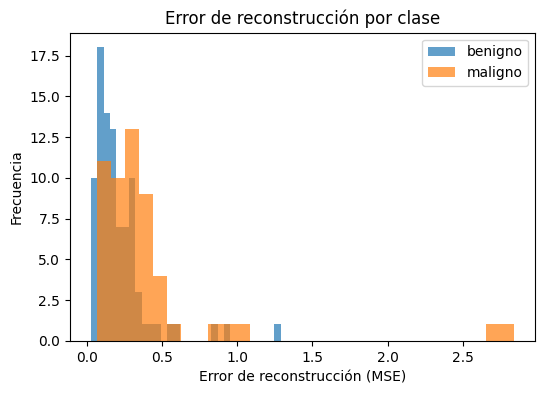

Media error benigno: 0.21232280169055165
Media error maligno: 0.4092065061692005


In [ ]:
# 7) (Bonus) Detección de anomalías con error de reconstrucción
# =========================
# 7) BONUS: RECONSTRUCTION ERROR = ANOMALÍA
# =========================
# Error de reconstrucción en test

# Esa parte del código se refiere a usar el autoencoder no como herramienta de compresión
# para clasificación, sino como detector de anomalías, basándose en el error de reconstrucción.
# Idea principal
# El autoencoder aprende a “copiar” la entrada en la salida.
# Si el modelo fue entrenado con datos "normales" o "representativos", sabrá reconstruirlos muy bien.

# Cuando ve un dato “raro” o anómalo, su reconstrucción será mala, porque no encaja con el patrón aprendido.
# El error de reconstrucción (diferencia entre entrada y salida) sirve como indicador:
# Error pequeño → dato típico.
# Error grande → posible anomalía.

# Flujo general
# Entrenamiento:

# Se entrena el autoencoder con los datos de entrenamiento.

# Aprende a codificar y decodificar patrones normales.

# Predicción:

# Pasas los datos por el autoencoder y calculas:
# error=(1/𝑛)∑𝑖=1 hasta 𝑛 (𝑥𝑖−𝑥^𝑖)2
# donde 𝑥𝑖 es el valor original y 𝑥^𝑖 es el reconstruido.

# Detección:
# Definir un umbral (threshold) usando estadísticas del error en datos normales.
# Si el error de una nueva muestra supera el umbral → marcar como anomalía.

# Ejemplo práctico
# En un dataset de cáncer de mama:
# Si entrenas el autoencoder solo con tumores benignos, aprenderá a reconstruirlos bien.
# Cuando le das un tumor maligno (que no estaba en el patrón aprendido), el error aumenta → lo detecta como “fuera de lo normal”.


X_te_rec = auto.predict(X_te_std)
rec_err = np.mean((X_te_std - X_te_rec)**2, axis=1)

plt.figure(figsize=(6,4))
plt.hist(rec_err[y_te==1], bins=30, alpha=0.7, label="benigno")
plt.hist(rec_err[y_te==0], bins=30, alpha=0.7, label="maligno")
plt.xlabel("Error de reconstrucción (MSE)")
plt.ylabel("Frecuencia")
plt.title("Error de reconstrucción por clase")
plt.legend()
plt.show()

print("Media error benigno:", rec_err[y_te==1].mean())
print("Media error maligno:", rec_err[y_te==0].mean())

X_te_rec = auto.predict(X_te_std)
auto es el autoencoder previamente entrenado.

X_te_std son los datos de prueba estandarizados.

auto.predict(...) pasa los datos por el autoencoder para obtener la reconstrucción (𝑋^).

X_te_rec contendrá la versión reconstruida de cada muestra.

 Objetivo: ver qué tan bien el autoencoder puede "copiar" los datos originales.

 Cálculo del error de reconstrucción
rec_err = np.mean((X_te_std - X_te_rec)**2, axis=1)
X_te_std - X_te_rec → calcula la diferencia entre cada valor real y reconstruido.

**2 → eleva al cuadrado para penalizar más los errores grandes.

np.mean(..., axis=1) → promedia el error para cada muestra (no por variable), obteniendo un valor MSE (Mean Squared Error) por fila.

 Resultado: rec_err es un vector de errores, uno por cada muestra de test.

 Graficar histograma por clase
plt.hist(rec_err[y_te==1], bins=30, alpha=0.7, label="benigno")
plt.hist(rec_err[y_te==0], bins=30, alpha=0.7, label="maligno")
y_te son las etiquetas verdaderas de prueba:

1 → benigno

0 → maligno

rec_err[y_te==1] → selecciona solo errores de los benignos.

rec_err[y_te==0] → selecciona solo errores de los malignos.

bins=30 → 30 barras en el histograma.

alpha=0.7 → transparencia para que las barras se vean superpuestas.

label → nombre que saldrá en la leyenda.

Objetivo: comparar visualmente los errores de reconstrucción entre las dos clases.

Etiquetas y título
plt.xlabel("Error de reconstrucción (MSE)")
plt.ylabel("Frecuencia")
plt.title("Error de reconstrucción por clase")
plt.legend()
plt.show()
Configura el aspecto del gráfico.

El histograma mostrará dos distribuciones de error (benignos vs malignos).

Calcular la media de error por clase
print("Media error benigno:", rec_err[y_te==1].mean())
print("Media error maligno:", rec_err[y_te==0].mean())
Calcula el promedio del error para cada grupo.

En general:

Si el autoencoder fue entrenado con datos benignos, el error en benignos será menor.

Los malignos tendrán mayor error, porque el modelo no sabe reconstruirlos bien.

En este caso, las clases son:

Benigno (etiqueta 1, azul)

Maligno (etiqueta 0, naranja)

El autoencoder aprende a reconstruir datos.

Si los datos son “similares” a lo que vio en el entrenamiento → error bajo.

Si son diferentes → error alto.

En este caso, las clases son:

Benigno (etiqueta 1, azul)

Maligno (etiqueta 0, naranja)
Interpretación del gráfico
Eje X: error de reconstrucción (MSE por muestra)

Eje Y: frecuencia de ocurrencia

Azul (benigno): la mayoría de los casos tienen error muy bajo, cerca de 0–0.2.

Naranja (maligno): aunque algunos también tienen error bajo, muchos se extienden hacia errores más altos (0.5, 1, hasta 2.5).

Esto sugiere que el autoencoder reconstruye mucho mejor los benignos que los malignos.

Interpretación de las medias
Media error benigno: 0.2123
→ en promedio, el autoencoder comete poco error al reconstruir benignos.

Media error maligno: 0.4092
→ el doble de error que en benignos, lo que indica que los malignos son más “extraños” para el modelo.

4️Conclusión
Hay una separación estadística clara: malignos tienden a tener mayor error de reconstrucción.

Esto abre la puerta a usar un umbral de error para clasificar:

Error bajo → probablemente benigno.

Error alto → posible maligno (anomalía).

Ejemplo de decisión: si fijamos un umbral en 0.30, muchos benignos quedarían correctamente clasificados, y gran parte de los malignos serían detectados como anómalos.

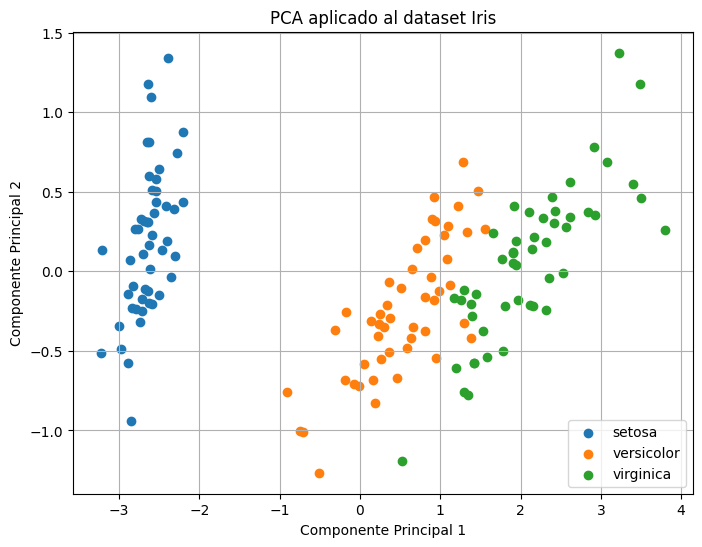

In [ ]:
# 1. PCA (Análisis de Componentes Principales)
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Cargar el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualizar los resultados
plt.figure(figsize=(8,6))
for label in np.unique(y):
    plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1], label=iris.target_names[label])
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA aplicado al dataset Iris')
plt.legend()
plt.grid(True)
plt.show()

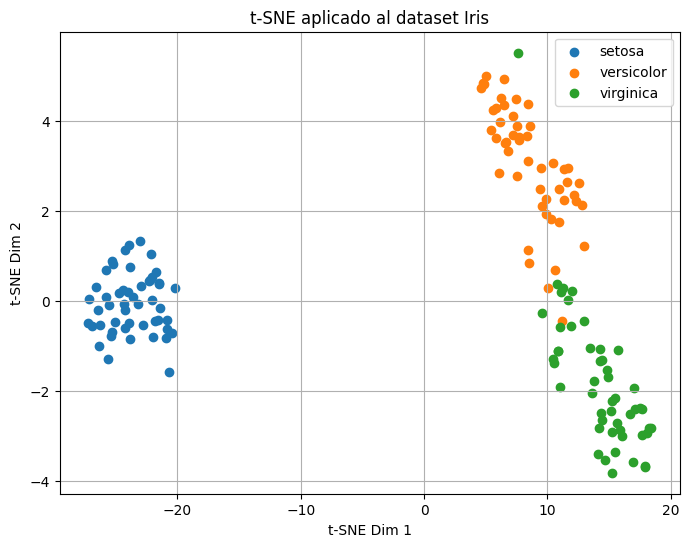

In [ ]:
# 2. t-SNE (t-distributed Stochastic Neighbor Embedding)
from sklearn.manifold import TSNE

# Aplicar t-SNE para reducir a 2 dimensiones
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Visualizar los resultados
plt.figure(figsize=(8,6))
for label in np.unique(y):
    plt.scatter(X_tsne[y == label, 0], X_tsne[y == label, 1], label=iris.target_names[label])
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.title('t-SNE aplicado al dataset Iris')
plt.legend()
plt.grid(True)
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


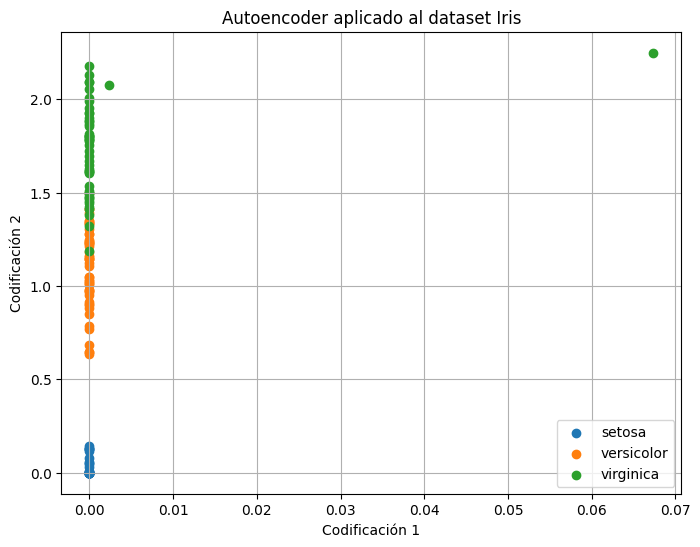

In [ ]:
# 3. Autoencoders (Redes Neuronales para Reducción Dimensional)
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

# Normalizar los datos
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
# Escala cada variable a [0, 1].
# Importante porque al final usas sigmoid en la salida (que también da valores en [0,1]) y la pérdida es MSE entre X y X̂.

# Definir el autoencoder
input_dim = X_scaled.shape[1] # # 4 en Iris
encoding_dim = 2  # Reducimos a 2 dimensiones para graficar

input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(encoding_dim, activation='relu')(input_layer)
decoded = layers.Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = models.Model(input_layer, decoded)
encoder = models.Model(input_layer, encoded)
# Encoder (4 → 2) con ReLU: comprime las 4 variables (sépalos y pétalos) a 2 números (la latente).
# Decoder (2 → 4) con sigmoid: reconstruye la entrada; sigmoid tiene sentido porque los datos están en [0,1].
# Es un autoencoder muy simple (una capa por lado). Sirve para una demo rápida y para obtener una proyección 2D.

# Compilar y entrenar
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=16, verbose=0)
# Objetivo: que la salida X̂ sea lo más parecida posible a la entrada X (minimizando MSE).
# No usa etiquetas; aprende patrones de los datos.
# 100 épocas, batch 16; sin validación.
# Épocas = 100

# Una época es pasar por todo el conjunto de entrenamiento una vez.
# Si tienes, por ejemplo, 150 flores en Iris y 100 épocas:
# El modelo verá esas 150 muestras completas 100 veces.

# Cuantas más épocas, más oportunidad de aprender… pero también más riesgo de sobreajuste (overfitting).

# 2) Batch = 16
# Un batch (lote o minibatch) es el número de muestras procesadas antes de actualizar los pesos del modelo.
# Con batch_size = 16, el modelo:
# Toma 16 muestras → calcula el error y gradientes → actualiza los pesos → sigue con las siguientes 16.
# Para Iris (150 muestras):
# Cada época tendrá 150 / 16 ≈ 10 actualizaciones.
# Lotes pequeños → actualizaciones más frecuentes pero con más ruido.
# Lotes grandes → más estables pero más lentos por época.

# Aquí le estamos diciendo a Keras:
# “Entrena 100 rondas completas sobre todos los datos y, en cada ronda, procesa los datos en grupos de 16 muestras antes de ajustar los pesos.”

# Obtener la representación reducida
X_encoded = encoder.predict(X_scaled)

# Visualizar
plt.figure(figsize=(8,6))
for label in np.unique(y):
    plt.scatter(X_encoded[y == label, 0], X_encoded[y == label, 1], label=iris.target_names[label])
plt.xlabel('Codificación 1')
plt.ylabel('Codificación 2')
plt.title('Autoencoder aplicado al dataset Iris')
plt.legend()
plt.grid(True)
plt.show()
# encoder.predict te da la representación comprimida (Z) de dimensión 2 para cada flor.
# Se grafica en 2D, coloreando por especie (setosa, versicolor, virginica).

Ejes y codificación
Codificación 1 (eje X) y Codificación 2 (eje Y) son las dos features (características) aprendidas por la capa de compresión (encoding layer) del autoencoder.

El autoencoder recibe las 4 variables originales del dataset Iris (largo y ancho de sépalos y pétalos) y aprende una representación comprimida de solo 2 números para cada flor.

Colores y clases
Cada punto es una flor del dataset Iris.

Los colores representan la etiqueta real:

Azul = setosa

Naranja = versicolor

Verde = virginica

Interpretación de la distribución
Se nota que la mayoría de los puntos tienen Codificación 1 ≈ 0 y están alineados verticalmente.

Esto significa que la primera dimensión aprendida no está variando mucho, y la separación entre clases está ocurriendo más en la Codificación 2 (eje Y).

Setosa (azul) está bien separada en la parte baja,
Versicolor (naranja) está en la zona media,
Virginica (verde) arriba.

Hay un par de puntos verdes y naranjas más dispersos, lo que sugiere que el autoencoder no separó perfectamente esas clases.

Por qué no se ve como el PCA o t-SNE
Un autoencoder no está optimizado para separar clases; su objetivo es reconstruir los datos originales desde la codificación comprimida.

La estructura que ves es consecuencia de cómo el modelo comprimió la información para reconstruirla, no de una optimización para visualización.

Si hubieras usado más neuronas en la capa oculta o más épocas, la separación podría mejorar.

In [ ]:
# Clase Lunes 11/08/2025 sesión 3 del módulo 7
# 0) Setup común (librerías y datos de ejemplo)
# =========================
# SETUP COMÚN (EJECUTA PRIMERO)
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn

print("Versión scikit-learn:", sklearn.__version__)

# Dataset pequeño y clásico para demos rápidas:
iris = load_iris()
X_iris = iris.data         # (150, 4) -> 4 variables (alto/ancho sépalos y pétalos)
y_iris = iris.target       # 3 clases

# Estandarizamos (muy recomendable para PCA y t-SNE)
scaler_iris = StandardScaler()
X_iris_std = scaler_iris.fit_transform(X_iris)

print("Iris estandarizado:", X_iris_std.shape)

# Para el autoencoder usaremos MNIST reducido (digits de sklearn: 8x8 = 64 pixeles)
digits = load_digits()
X_digits = digits.data / 16.0  # normalizamos a [0,1]
y_digits = digits.target
print("Digits:", X_digits.shape)

Versión scikit-learn: 1.6.1
Iris estandarizado: (150, 4)
Digits: (1797, 64)


Forma original: (150, 4)
Forma reducida (PCA 2D): (150, 2)
Varianza explicada por cada componente: [0.72962445 0.22850762]
Varianza explicada acumulada: 0.9581320720000166


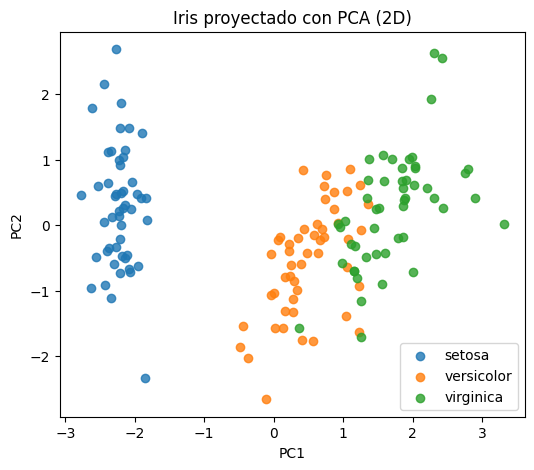

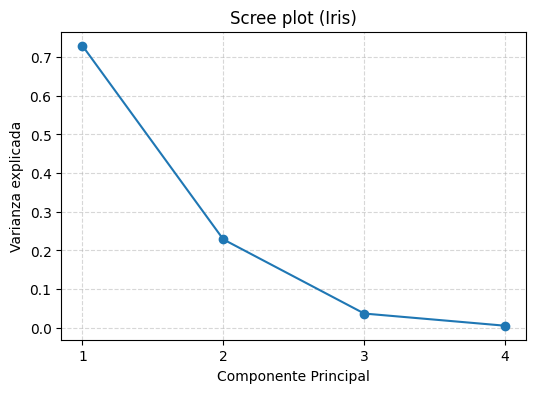

Matriz de carga (loadings) W (autovectores):
[[ 0.52106591  0.37741762]
 [-0.26934744  0.92329566]
 [ 0.5804131   0.02449161]
 [ 0.56485654  0.06694199]]


In [ ]:
# PCA: reducción lineal + visualización y varianza explicada
# =========================
# PCA BÁSICO (con Iris)
# =========================
from sklearn.decomposition import PCA

# Queremos reducir a 2 componentes para graficar en 2D:
pca = PCA(n_components=2, random_state=42)
X_iris_pca = pca.fit_transform(X_iris_std)

print("Forma original:", X_iris_std.shape)
print("Forma reducida (PCA 2D):", X_iris_pca.shape)
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

# Gráfico 2D de los dos componentes principales
plt.figure(figsize=(6,5))
for clase in np.unique(y_iris):
    plt.scatter(
        X_iris_pca[y_iris == clase, 0],
        X_iris_pca[y_iris == clase, 1],
        label=iris.target_names[clase],
        alpha=0.8
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Iris proyectado con PCA (2D)")
plt.legend()
plt.show()

# Scree plot (varianza explicada por componente) para todas las PCs
pca_full = PCA()  # si no pasamos n_components, calcula todas
pca_full.fit(X_iris_std)

plt.figure(figsize=(6,4))
plt.plot(np.arange(1, X_iris_std.shape[1]+1), pca_full.explained_variance_ratio_, marker="o")
plt.xticks(range(1, X_iris_std.shape[1]+1))
plt.xlabel("Componente Principal")
plt.ylabel("Varianza explicada")
plt.title("Scree plot (Iris)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Proyección nueva de datos (ejemplo conceptual): X_reducido = X * W
# Donde W son los autovectores (componentes) seleccionados
W = pca.components_.T  # (4, 2) ejes de proyección
print("Matriz de carga (loadings) W (autovectores):")
print(W)

# muestra cómo PCA “concentra” la varianza en pocas direcciones y cómo leer la varianza explicada para decidir cuántos componentes conservar.

 Forma original: (150, 4)
150: número de observaciones (flores del dataset Iris).

4: número de variables originales (largo sépalo, ancho sépalo, largo pétalo, ancho pétalo).

2. Forma reducida (PCA 2D): (150, 2)
Después de aplicar PCA con n_components=2, cada flor se representa solo con 2 coordenadas (PC1 y PC2) en lugar de 4.

El objetivo: conservar la mayor parte de la información (varianza) usando menos dimensiones.

3. Varianza explicada por cada componente
[0.72962445, 0.22850762]
PC1 (0.7296): explica el 72.96 % de la variabilidad total de los datos.

PC2 (0.2285): explica el 22.85 % adicional.

4. Varianza explicada acumulada
0.9581320720000166
95.81 % de la información total del dataset se conserva con solo 2 componentes principales.

Por eso, en el scree plot, después de PC2 la varianza añadida es muy pequeña.

5. Matriz de carga (W) – Autovectores
[[ 0.52106591  0.37741762]
 [-0.26934744  0.92329566]
 [ 0.5804131   0.02449161]
 [ 0.56485654  0.06694199]]
Cada fila corresponde a una variable original (en el orden del dataset Iris).

Largo sépalo

Ancho sépalo

Largo pétalo

Ancho pétalo

Cada columna es un componente principal (PC1 y PC2).

Los valores indican el peso (coeficiente) con que cada variable original contribuye a ese componente:

PC1 (columna 1): recibe fuertes contribuciones de largo sépalo, largo pétalo y ancho pétalo (valores positivos grandes).

PC2 (columna 2): está dominado por el ancho sépalo (0.923), y en menor medida por el largo sépalo.

Interpretación docente:

PC1 es una medida global de “tamaño” (flor más grande o más pequeña).

PC2 distingue principalmente por ancho del sépalo.

Esto concuerda con la gráfica: la separación horizontal (PC1) diferencia mucho a setosa del resto, y la vertical (PC2) separa parcialmente versicolor y virginica.

Forma t-SNE: (150, 2)


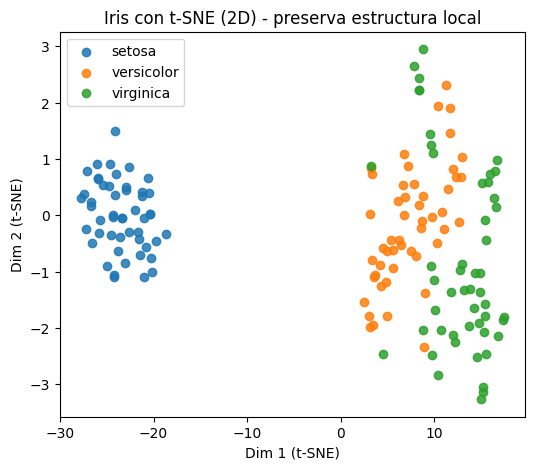

In [ ]:
# 2) t-SNE: reducción no lineal para visualización (estructura local)
# =========================
# t-SNE (con Iris)
# =========================
from sklearn.manifold import TSNE

# t-SNE es sensible a escala -> usar datos estandarizados.
# Perplexity típicamente entre 5 y 50 (probar varias). random_state para reproducibilidad.
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
X_iris_tsne = tsne.fit_transform(X_iris_std)

print("Forma t-SNE:", X_iris_tsne.shape)

plt.figure(figsize=(6,5))
for clase in np.unique(y_iris):
    plt.scatter(
        X_iris_tsne[y_iris == clase, 0],
        X_iris_tsne[y_iris == clase, 1],
        label=iris.target_names[clase],
        alpha=0.85
    )
plt.xlabel("Dim 1 (t-SNE)")
plt.ylabel("Dim 2 (t-SNE)")
plt.title("Iris con t-SNE (2D) - preserva estructura local")
plt.legend()
plt.show()

# Nota docente:
# - t-SNE no es un método de proyección lineal, su objetivo es visualización.
# - Puede variar entre corridas (aún con random_state, cambia si cambias parámetros).
# Sugerencia: Probar distintos perplexity (p.ej., 5, 30, 50) y comparar.

1. 150 filas
Corresponde a las 150 observaciones del dataset Iris (150 flores).

2. 2 columnas
Después de aplicar t-SNE, cada flor está representada en 2 dimensiones:

Dim 1 (t-SNE)

Dim 2 (t-SNE)

Estas dos dimensiones son coordenadas nuevas calculadas por el algoritmo para preservar la estructura local de los datos en un espacio reducido, ideal para visualización.

Diferencia con PCA
En PCA, las nuevas dimensiones (componentes) son combinaciones lineales de las variables originales y se pueden interpretar directamente.

En t-SNE, las dimensiones no son lineales ni interpretables de la misma forma: su objetivo no es explicar varianza global, sino que los puntos que estaban cercanos en el espacio original sigan cercanos en el espacio reducido.

Interpretación de la gráfica
Cada punto = una flor.

Colores = especie (setosa, versicolor, virginica).

Las distancias dentro de un grupo son significativas: si dos puntos están cerca aquí, es porque también estaban cerca en el espacio original de 4 variables.

El hecho de que setosa esté muy separada horizontalmente indica que sus características originales eran muy diferentes de las otras especies, algo que t-SNE captó.

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_32 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_16 (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_32 (Dense)                  │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 64)             │         2,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,264 (20.56 KB)

 Trainable params: 5,264 (20.56 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1741 - val_loss: 0.1455
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1293 - val_loss: 0.0893
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0818 - val_loss: 0.0722
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0694 - val_loss: 0.0661
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0634 - val_loss: 0.0600
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0574 - val_loss: 0.0536
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0514 - val_loss: 0.0481
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0465 - val_loss: 0.0441
Epoch 9/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0423 - val_loss: 0.0410
Epoch 10/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0391 - val_loss: 0.0386
Epoch 11/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0371 - val_loss: 0.0370
Epoch 12/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0355 - val_l

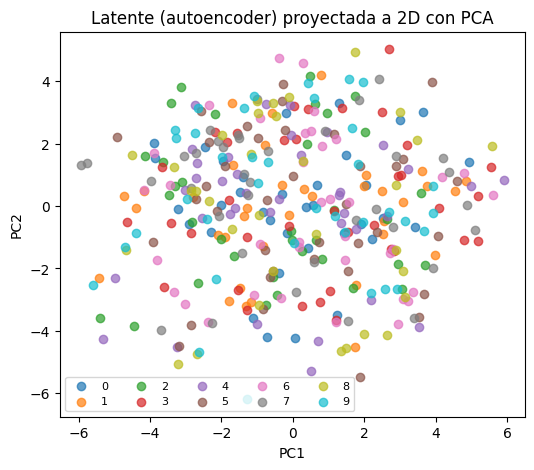

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


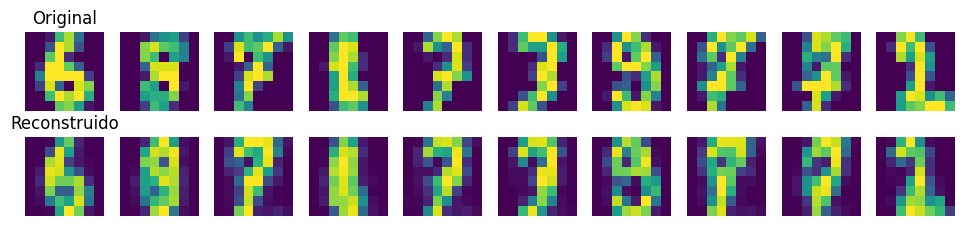

In [ ]:
# 3) Autoencoder: reducción no lineal aprendida (Keras/TensorFlow)
# =========================
# AUTOENCODER DENSO (con Digits 8x8)
# =========================
# Si estás en Colab, TensorFlow ya está disponible. Usamos una arquitectura pequeña y rápida.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Dividimos train/test
X_tr, X_te = train_test_split(X_digits, test_size=0.2, random_state=42, stratify=y_digits)

input_dim = X_tr.shape[1]     # 64 (8x8)
encoding_dim = 16             # dimensión comprimida (ajustable)
# TensorFlow/Keras: para construir y entrenar la red.

# train_test_split(..., stratify=y_digits): divide 80/20 manteniendo la proporción de clases en train y test.

# input_dim = 64: cada imagen 8×8 se “aplana” a un vector de 64 píxeles.

# encoding_dim = 16: tamaño del cuello de botella (representación latente). Si lo reduces, comprimes más.

# ----- Definición del modelo -----
input_layer = keras.Input(shape=(input_dim,), name="entrada")
# Codificador: reduce de 64 -> 32 -> 16
encoded = layers.Dense(32, activation="relu", name="enc_32")(input_layer)
encoded = layers.Dense(encoding_dim, activation="relu", name="enc_16")(encoded)

# Decodificador: reconstruye 16 -> 32 -> 64
decoded = layers.Dense(32, activation="relu", name="dec_32")(encoded)
decoded = layers.Dense(input_dim, activation="sigmoid", name="salida")(decoded)

autoencoder = keras.Model(input_layer, decoded, name="autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()
# Codificador (encoder): aprende a comprimir los 64 números a 16.

# Decodificador (decoder): desde esos 16, intenta reconstruir los 64 originales.

# ReLU en capas ocultas: introduce no linealidad y acelera el aprendizaje.

# Sigmoid en salida: produce valores en [0,1] (nuestros píxeles se normalizaron a [0,1]).

# Pérdida MSE: penaliza el error de reconstrucción (X ≈ X̂).

# Adam: optimizador robusto por defecto.


# Entrenamos para reconstruir la entrada (X -> X)
hist = autoencoder.fit(
    X_tr, X_tr,
    validation_data=(X_te, X_te),
    epochs=30,
    batch_size=64,
    verbose=1
)
# Objetivo: el modelo recibe X y debe devolver X (reconstrucción).

# validation_data: monitorea sobreajuste comparando train vs test.

# epochs / batch_size: hiperparámetros estándar; puedes ajustar.


# Modelo "encoder" para obtener la representación comprimida
encoder = keras.Model(input_layer, encoded, name="encoder")
# Se define un submodelo que llega hasta la capa enc_16.
# Z es la representación latente (dimensión 16). Es lo “útil” para visualización, compresión o detección de anomalías.


# Obtenemos las representaciones comprimidas y graficamos en 2D con PCA
Z_tr = encoder.predict(X_tr)
Z_te = encoder.predict(X_te)

print("Forma latente (train):", Z_tr.shape) #  # (n_muestras, 16)

# Opcional: proyectar la latente a 2D con PCA para visualizar clusters de dígitos
pca_latent = PCA(n_components=2, random_state=42)
Z_te_2d = pca_latent.fit_transform(Z_te)

plt.figure(figsize=(6,5))
for dig in np.unique(y_digits):
    idx = (y_digits[digits.data.shape[0]-X_te.shape[0]:] == dig)  # indices de test en y_digits
    plt.scatter(Z_te_2d[idx, 0], Z_te_2d[idx, 1], alpha=0.7, label=str(dig))
plt.title("Latente (autoencoder) proyectada a 2D con PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(ncol=5, fontsize=8)
plt.show()
# Se aplica PCA a Z_te para bajarlo a 2D y graficar.
# El idx = (...) identifica qué puntos del conjunto de test pertenecen a cada dígito.


# Visualizar reconstrucciones vs originales
n = 10
idx = np.random.choice(len(X_te), size=n, replace=False)
X_sample = X_te[idx]
X_recon = autoencoder.predict(X_sample)

fig, axes = plt.subplots(2, n, figsize=(1.2*n, 2.5))
for i in range(n):
    # Original
    axes[0, i].imshow(X_sample[i].reshape(8,8), interpolation="nearest")
    axes[0, i].axis("off")
    if i == 0: axes[0, i].set_title("Original")
    # Reconstrucción
    axes[1, i].imshow(X_recon[i].reshape(8,8), interpolation="nearest")
    axes[1, i].axis("off")
    if i == 0: axes[1, i].set_title("Reconstruido")
plt.show()

# Nota docente:
# - El autoencoder aprende una representación comprimida (codificador) que luego sirve
#   para visualización, compresión o detección de anomalías (si la reconstrucción sale mala).

Objetivo: comprimir la información original (64 píxeles) a un espacio de menor dimensión (16 números).

Primera capa (enc_32):

Dense(32) = capa densa con 32 neuronas.

Recibe un vector de 64 elementos (imagen aplanada 8×8) y lo transforma a 32.

activation="relu" introduce no linealidad y ayuda a que la red aprenda patrones complejos.

Segunda capa (enc_16):

Reduce los 32 valores a encoding_dim (aquí = 16), que es la representación latente o cuello de botella.

Esta es la codificación comprimida que guarda la información más importante para reconstruir la imagen.

Decodificador
python
Copiar
Editar
# Decodificador: reconstruye 16 -> 32 -> 64
decoded = layers.Dense(32, activation="relu", name="dec_32")(encoded)
decoded = layers.Dense(input_dim, activation="sigmoid", name="salida")(decoded)
Objetivo: reconstruir la entrada original a partir de la latente (16 valores).

Primera capa (dec_32):

Expande de 16 → 32 neuronas.

Vuelve a introducir no linealidad con relu.

Segunda capa (salida):

Expande de 32 → 64 neuronas (número original de píxeles).

activation="sigmoid" asegura valores entre 0 y 1, que coincide con el rango de los píxeles normalizados.

Aquí se obtiene la imagen reconstruida.

Creación y compilación del modelo
autoencoder = keras.Model(input_layer, decoded, name="autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()
keras.Model(input_layer, decoded):

Define el modelo completo, desde la entrada original (input_layer) hasta la salida reconstruida (decoded).

Compilación:

optimizer="adam": optimizador adaptativo que ajusta los pesos durante el entrenamiento.

loss="mse" (Error Cuadrático Medio): mide qué tan parecida es la reconstrucción a la imagen original (promedio de los cuadrados de las diferencias).

summary():

Muestra la arquitectura, capas, dimensiones de salida y número de parámetros entrenables.

Un autoencoder no usa etiquetas (es aprendizaje no supervisado).

Su tarea es reproducir su entrada en la salida.

Por eso, en .fit() tanto las entradas como las salidas son el mismo conjunto de datos:

Entrada (X_tr): imagen original.

Salida esperada (X_tr): la misma imagen original.

El modelo aprende a pasar por el cuello de botella (capa codificada) y luego reconstruir la imagen.

2. Parámetros:
X_tr, X_tr → entrenamiento: entradas y salidas idénticas.

validation_data=(X_te, X_te) → validación: comprueba si el modelo reconstruye bien imágenes que no ha visto durante el entrenamiento.

epochs=30 → el conjunto de entrenamiento se procesa 30 veces completas.

batch_size=64 → se procesan 64 imágenes a la vez antes de actualizar los pesos.

verbose=1 → muestra la barra de progreso y la pérdida en cada epoch.

3. Salida de .fit()
.fit() devuelve un objeto History (hist) que guarda:

hist.history['loss'] → pérdida de entrenamiento por epoch.

hist.history['val_loss'] → pérdida de validación por epoch.

Layer (type)         Output Shape   Param #
------------------------------------------------
entrada (InputLayer) (None, 64)            0
enc_32 (Dense)       (None, 32)        2,080
enc_16 (Dense)       (None, 16)          528
dec_32 (Dense)       (None, 32)          544
salida (Dense)       (None, 64)        2,112
------------------------------------------------
Total params: 5,264 (20.56 KB)
Trainable params: 5,264 (20.56 KB)
Non-trainable params: 0
Qué significa cada columna:

Layer (type): nombre y tipo de capa (Dense, InputLayer, etc.).

Output Shape: dimensión de salida de esa capa (None significa que puede variar el número de muestras en el batch).

Param #: cantidad de parámetros entrenables de la capa.

Cómo se calculan los parámetros en Dense:

Fórmula:
n_params=(n_entradas×n_neuronas)+n_bias
Ejemplo para enc_32:
(64×32)+32=2048+32=2,080 parámetros.

2. Entrenamiento (fit)
Cada línea Epoch x/30 muestra:

loss: error de reconstrucción en el conjunto de entrenamiento (MSE).

val_loss: error de reconstrucción en el conjunto de validación (imágenes no vistas).

Interpretación de la evolución:

Al inicio (Epoch 1):
loss: 0.1741 → el modelo reconstruye mal.
val_loss: 0.1455 → también alto en validación.

A medida que avanza:

La pérdida baja de forma constante hasta llegar a ~0.0209 en entrenamiento y ~0.0212 en validación.

El hecho de que loss y val_loss estén muy cerca indica buena generalización (no hay sobreajuste fuerte).

Tendencia: el autoencoder aprendió a reconstruir con muy poco error.

3. Predicciones finales
Forma latente (train): (1437, 16)
1437: número de muestras en el set de entrenamiento (X_tr).

16: dimensión de la representación comprimida (encoding_dim).

Esto confirma que el encoder transformó cada imagen (64 pixeles) en un vector de solo 16 números que contienen la información esencial para reconstruirla.

Epoch 1/30 → primera de 30 iteraciones completas sobre el dataset.

23/23 → número de lotes (batches) en una época (cada batch = 64 muestras).

2s 11ms/step → tiempo total de la época y promedio por batch.

loss → error de reconstrucción en el conjunto de entrenamiento (MSE).

En Epoch 1: 0.1741 (alto al inicio).

val_loss → error de reconstrucción en el conjunto de validación (datos no vistos).

En Epoch 1: 0.1455.

Al pasar de Epoch 1 a 4, tanto loss como val_loss bajan:

Significa que el autoencoder está aprendiendo a reconstruir con menos error.

Además, la reducción de val_loss indica que también generaliza bien.


1. Latente proyectada a 2D con PCA
Qué es:
El autoencoder comprimió cada imagen de 64 píxeles (8×8) a un vector de 16 valores (representación latente).
Luego, usamos PCA para reducir esos 16 valores a 2 dimensiones y poder graficarlos.

Ejes:

PC1 y PC2: combinaciones lineales que capturan la mayor varianza posible de la representación latente.

Colores:

Cada color representa una clase de dígito (0–9).

Interpretación:

Si el autoencoder hubiera aprendido una codificación que separa naturalmente las clases, veríamos agrupamientos por color.

En este gráfico, los colores están bastante mezclados, lo que indica que el autoencoder no fue entrenado para clasificar, sino para reconstruir, así que la latente no está optimizada para separar clases, aunque puede contener patrones útiles.

2. Original vs Reconstruido
Fila superior (Original):

Muestras reales del conjunto de prueba (imágenes originales 8×8).

Fila inferior (Reconstruido):

Imágenes generadas por el decodificador a partir de la latente de esas mismas imágenes.

Interpretación:

Cuanto más parecidas sean las imágenes de arriba y abajo, mejor está capturando y reconstruyendo el autoencoder.

Aquí las reconstrucciones conservan la forma general de los dígitos, aunque con cierto desenfoque, típico cuando se usa una capa intermedia pequeña (16 dimensiones) y entrenamiento no supervisado.

El desenfoque se debe a que el modelo prioriza reconstruir las características más importantes (forma global) y descarta detalles finos.

Conclusión para clase:

El primer gráfico muestra la representación interna (codificación) del autoencoder, útil para ver cómo “ve” los datos.

El segundo gráfico es la medida más directa de calidad: si la reconstrucción es fiel a la entrada.

Un autoencoder no supervisado no garantiza separación perfecta por clases, pero sí genera una codificación compacta capaz de recrear los datos.


In [ ]:
# 4) Selección de características (no es transformación): filtro, wrapper, embebido
# =========================
# SELECCIÓN DE CARACTERÍSTICAS (Iris)
#   - Filtro: SelectKBest con Información Mutua
#   - Wrapper: RFE con Regresión Logística
#   - Embebido: L1 (Lasso) con Regresión Logística
# =========================
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

X = X_iris  # sin estandarizar para mostrar pipeline correcto
y = y_iris

# (a) FILTRO: SelectKBest (elige las k mejores variables por criterio estadístico)
pipe_filter = Pipeline([
    ("scaler", StandardScaler()),
    ("kbest", SelectKBest(score_func=mutual_info_classif, k=2)),
    ("clf", LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_filter = cross_val_score(pipe_filter, X, y, cv=cv)
print("[Filtro] Acc media 5-fold:", scores_filter.mean().round(3))

# Ajustamos para ver qué columnas eligió
pipe_filter.fit(X, y)
mask = pipe_filter.named_steps["kbest"].get_support()
print("Características seleccionadas (Filtro):", np.array(iris.feature_names)[mask])

# (b) WRAPPER: RFE (usa un modelo para evaluar subsets iterativamente)
base_lr = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=base_lr, n_features_to_select=2)

pipe_rfe = Pipeline([
    ("scaler", StandardScaler()),
    ("rfe", rfe),
    ("clf", LogisticRegression(max_iter=1000))
])

scores_rfe = cross_val_score(pipe_rfe, X, y, cv=cv)
print("[Wrapper-RFE] Acc media 5-fold:", scores_rfe.mean().round(3))

pipe_rfe.fit(X, y)
mask_rfe = pipe_rfe.named_steps["rfe"].get_support()
print("Características seleccionadas (RFE):", np.array(iris.feature_names)[mask_rfe])

# (c) EMBEBIDO: L1 (Lasso) en Regresión Logística (penaliza y "apaga" coeficientes)
# NOTA: Para L1 conviene solver='liblinear' o 'saga'
pipe_l1 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(penalty="l1", C=1.0, solver="saga", max_iter=5000))
])

scores_l1 = cross_val_score(pipe_l1, X, y, cv=cv)
print("[Embebido-L1] Acc media 5-fold:", scores_l1.mean().round(3))

# Entrenamos y miramos coeficientes (qué tan "apagadas" quedan variables)
pipe_l1.fit(X, y)
coef = pipe_l1.named_steps["clf"].coef_  # (3 clases, 4 variables)
print("Coeficientes L1 (por clase):\n", np.round(coef, 3))
print("Importancia aproximada por variable (norma L1 promedio por columna):")
print(np.round(np.mean(np.abs(coef), axis=0), 3), "->", iris.feature_names)

# Clave didáctica:
# Filtro: decisión por métrica estadística (rápido).
# Wrapper (RFE): busca subconjunto “óptimo” usando un modelo (más costoso).
# Embebido (L1): el modelo hace selección durante el entrenamiento.



[Filtro] Acc media 5-fold: 0.953
Características seleccionadas (Filtro): ['petal length (cm)' 'petal width (cm)']
[Wrapper-RFE] Acc media 5-fold: 0.953
Características seleccionadas (RFE): ['petal length (cm)' 'petal width (cm)']
[Embebido-L1] Acc media 5-fold: 0.953
Coeficientes L1 (por clase):
 [[ 0.     0.924 -4.709  0.   ]
 [ 0.218  0.     0.     0.   ]
 [ 0.    -0.698  4.17   5.033]]
Importancia aproximada por variable (norma L1 promedio por columna):
[0.073 0.54  2.96  1.678] -> ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


[Filtro] Acc media 5-fold: 0.953
[Wrapper-RFE] Acc media 5-fold: 0.953
[Embebido-L1] Acc media 5-fold: 0.953
0.953 significa que en promedio el modelo clasificó correctamente el 95.3% de las muestras en validación cruzada.

Los tres métodos dieron la misma precisión media, lo que sugiere que seleccionaron características igualmente informativas para la tarea.

2. Características seleccionadas
pgsql
Copiar
Editar
[Filtro]: ['petal length (cm)', 'petal width (cm)']
[Wrapper-RFE]: ['petal length (cm)', 'petal width (cm)']
Tanto el método de filtro como el wrapper RFE coincidieron en que las dos características más relevantes son:

Longitud del pétalo (petal length).

Ancho del pétalo (petal width).

Esto tiene sentido biológico: en el dataset Iris, estas dos variables separan muy bien las especies.

3. Método embebido (L1)
lua
Copiar
Editar
Coeficientes L1 (por clase):
 [[ 0.     0.924 -4.709  0.   ]
 [ 0.218  0.     0.     0.   ]
 [ 0.    -0.698  4.17   5.033]]
Cada fila corresponde a una clase (0, 1, 2) en la regresión logística multiclase.

Cada columna es una característica:

Sepal length

Sepal width

Petal length

Petal width

Los valores indican el peso (coeficiente) asignado a esa característica para esa clase.

Un valor 0 implica que la regularización L1 eliminó esa característica para esa clase específica (no aporta en la decisión para esa clase).

4. Importancia promedio por característica
Importancia aproximada:
[0.073, 0.54, 2.96, 1.678]
-> ['sepal length', 'sepal width', 'petal length', 'petal width']
Calculada como la media del valor absoluto de los coeficientes por columna.

Interpretación:

petal length (2.96) → más importante.

petal width (1.678) → segunda más importante.

sepal width (0.54) → aporta algo, pero menos.

sepal length (0.073) → prácticamente irrelevante para este modelo.

Conclusión:

Los tres métodos (filtro, wrapper, embebido) coinciden en que petal length y petal width son las características clave para clasificar correctamente las flores Iris.

El método L1 confirma esto y además cuantifica la importancia relativa.

Esto refuerza que en problemas reales, varias técnicas pueden converger a las mismas variables más relevantes.

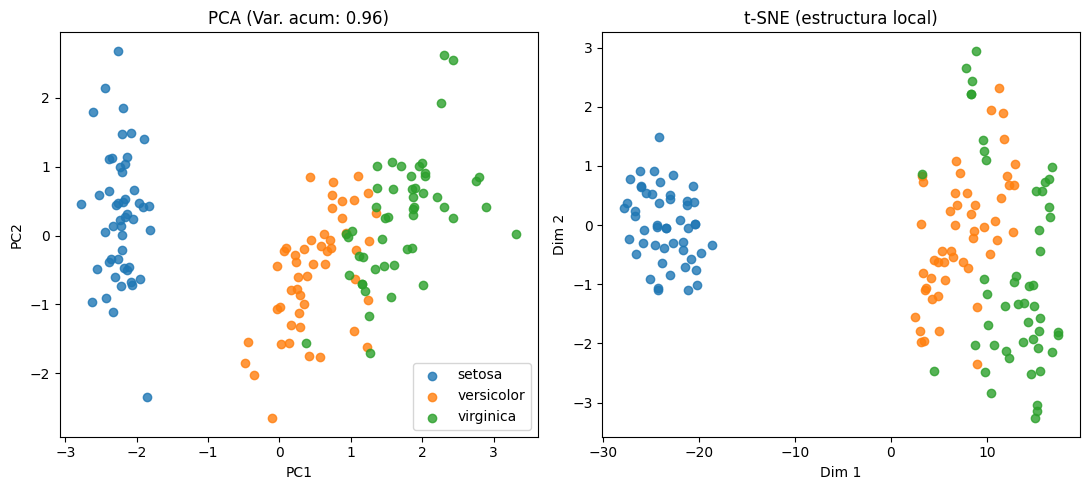

In [ ]:
# 5) Comparativa rápida: PCA vs t-SNE en el mismo dataset (Iris)
# =========================
# COMPARATIVA RÁPIDA: PCA vs t-SNE
# =========================
fig, axes = plt.subplots(1, 2, figsize=(11,5))

# PCA 2D
pca2 = PCA(n_components=2, random_state=42).fit(X_iris_std)
X_pca2 = pca2.transform(X_iris_std)
for c in np.unique(y_iris):
    axes[0].scatter(X_pca2[y_iris==c,0], X_pca2[y_iris==c,1], alpha=0.8, label=iris.target_names[c])
axes[0].set_title(f"PCA (Var. acum: {pca2.explained_variance_ratio_.sum():.2f})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# t-SNE 2D
tsne2 = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
X_tsne2 = tsne2.fit_transform(X_iris_std)
for c in np.unique(y_iris):
    axes[1].scatter(X_tsne2[y_iris==c,0], X_tsne2[y_iris==c,1], alpha=0.8, label=iris.target_names[c])
axes[1].set_title("t-SNE (estructura local)")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

# Observación:
# - PCA: conserva varianza global, lineal y explicable (componentes = combinaciones lineales).
# - t-SNE: muestra mejor separación local para visualización, pero no es lineal ni explicable igual que PCA.

Se solicita:

Cambiar n_components en PCA y analizar la varianza acumulada.

Probar perplexity en t-SNE (5, 30, 50) y comparar patrones.

Modificar encoding_dim del autoencoder (8, 16, 32) y ver cómo afecta la reconstrucción.

Comparar accuracies entre filtro, RFE y L1 y ver qué variables eligen.

PCA (izquierda)
Título: PCA (Var. acum: 0.96) → los dos primeros componentes principales retienen el 96% de la varianza total de los datos.

Ejes: PC1 y PC2 son combinaciones lineales de las variables originales que maximizan la varianza global.

Interpretación visual:

Setosa (azul) está perfectamente separada de las otras dos especies.

Versicolor (naranja) y Virginica (verde) muestran cierta superposición.

La separación se basa en diferencias globales en los datos.

Ventaja: escalas interpretables y reproducibles.

Limitación: no captura relaciones no lineales.

2. t-SNE (derecha)
Título: t-SNE (estructura local) → preserva relaciones de cercanía entre puntos, no la varianza global.

Ejes: Dim 1 y Dim 2 no tienen interpretación directa como combinación de variables originales.

Interpretación visual:

Setosa (azul) también aparece completamente separada.

Versicolor y Virginica se agrupan de forma más compacta que en PCA, con fronteras más definidas, aunque puede haber algo de mezcla.

La distancia entre grupos no es comparable a la de PCA (t-SNE no conserva distancias globales, solo las locales).

Ventaja: mejor agrupación visual para datos con estructuras complejas.

Limitación: no lineal, sensible a hiperparámetros y no reproducible al 100%.